# 사용자 가입 분석 (Accquisition)

* 서비스 특성 : 중·고등학생 타깃 특성상 리텐션(Retention)이 높아도 진급 및 졸업으로 인한 구조적 자연 이탈이 불가피한 특성을 가지고 있습니다.

* 이탈분을 상쇄하고 지속 가능한 성장을 도모하기 위해, 체계적인 신규 사용자 획득 (`Accquisition`)이 필수 과제라고 판단됩니다.

## 라이브러리 호출

In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
sns.set_theme(style="darkgrid")

plt.rc('font', family='AppleGothic')
# 마이너스 폰트 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

## 데이터 호출

In [51]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [52]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.stg_acquisition_user`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

   user_id                      signup_date  group_id  grade  school_id  \
0  1451324 2023-05-22 11:15:59.593841+00:00     57794      1       2728   
1  1133119 2023-05-11 12:43:14.933676+00:00     11813      1       2472   
2  1436161 2023-05-21 15:21:52.771027+00:00     72170      1       3628   
3  1124317 2023-05-11 08:55:50.477630+00:00     33298      1       3875   
4  1251132 2023-05-14 06:30:03.954539+00:00     10957      1       4916   

     address school_type  
0  부산광역시 사하구           H  
1  서울특별시 강서구           H  
2   경상북도 울진군           H  
3   경상북도 구미시           H  
4    경기도 양주시           H  


## 월별 가입자 추이 분석 & 학사일정 비교

In [53]:
# datetime 변환 후 YYYY-MM 포맷으로 추출
df['signup_month'] = pd.to_datetime(df['signup_date']).dt.strftime('%Y-%m')

# 연월별 유니크 가입자 수 집계
monthly_summary = df.groupby(by='signup_month')['user_id'].nunique().reset_index(name='unique_users')
# 실제 전월과 비교하도록 누락된 월도 포함하고 시간순으로 정렬
monthly_summary = (
    monthly_summary.set_index('signup_month')
    .reindex(
        pd.period_range(
            monthly_summary['signup_month'].min(),
            monthly_summary['signup_month'].max(),
            freq='M',
        ).astype(str),
        fill_value=0,
    )
    .rename_axis('signup_month')
    .reset_index()
)
monthly_summary['monthly_change'] = monthly_summary['unique_users'].diff()

print(monthly_summary.head())

  signup_month  unique_users  monthly_change
0      2023-03            22             NaN
1      2023-04         19030         19008.0
2      2023-05        635478        616448.0
3      2023-06         16732       -618746.0
4      2023-07          1832        -14900.0


In [54]:
def plot_monthly_signups(data, title):
    fig, ax = plt.subplots(figsize=(16, 6))

    # 라인그래프 생성
    sns.lineplot(
        data=data,
        x='signup_month',
        y='unique_users',
        marker='o',
        linewidth=2.5,
        color='#3182bd',
        ax=ax,
    )

    # 표시된 월별 가입자 수의 중앙값
    median_users = data['unique_users'].median()
    ax.axhline(
        y=median_users,
        color='darkorange',
        linestyle='--',
        linewidth=1.5,
        label=f'중앙값: {median_users:,.0f}명',
    )
    ax.legend(loc='upper right')

    # 각 데이터 포인트에 숫자 레이블 표시
    for row in data.itertuples(index=False):
        x, y, change = (
            row.signup_month,
            row.unique_users,
            row.monthly_change,
        )
        # 중앙값 이상인 월의 가입자 수 강조
        is_above_median = y >= median_users
        ax.annotate(
            f'{int(y):,}명',
            (x, y),
            xytext=(0, 23),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color='black',
            fontweight='bold' if is_above_median else 'normal',
            bbox=(
                dict(
                    boxstyle='round,pad=0.25',
                    facecolor='#FFF3CD',
                    edgecolor='darkorange',
                    linewidth=0.8,
                )
                if is_above_median else None
            ),
        )

        # 전월 대비 증감량
        if pd.isna(change):
            label, color = '전월 비교 없음', 'gray'
        elif change > 0:
            label, color = f'전월 대비 +{int(change):,}명', 'red'
        elif change < 0:
            label, color = f'전월 대비 {int(change):,}명', 'blue'
        else:
            label, color = '전월 대비 0명', 'gray'

        ax.annotate(
            label,
            (x, y),
            xytext=(0, 7),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color=color,
        )

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('가입 월', fontsize=11)
    ax.set_ylabel('가입 유저 수(명)', fontsize=11)

    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim(0, data['unique_users'].max() * 1.25)

    fig.tight_layout()
    plt.show()

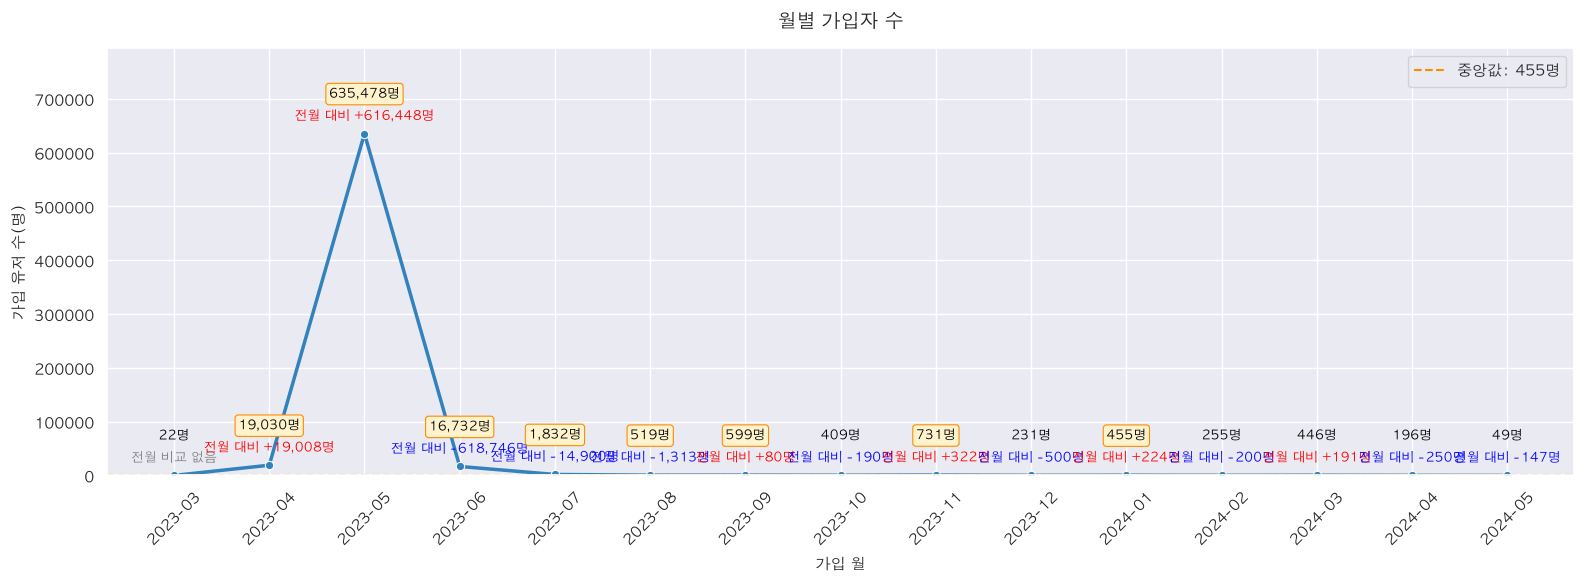

In [55]:
plot_monthly_signups(monthly_summary, '월별 가입자 수')


* 5월 가입자 수가 폭발적으로 증가했으나, 6월에 급격히 꺾이며 상승세가 일회성에 그침

* 5월의 급격한 증가로 인해 다른 월의 추이가 명확히 드러나지 않아, 5월을 제외한 후 추이를 재확인함

In [56]:
# 5월 제외 후 추이 재확인용 데이터
monthly_summary_ex_may = monthly_summary[
    ~monthly_summary['signup_month'].str.endswith('-05')
].reset_index(drop=True)

print(monthly_summary_ex_may)

   signup_month  unique_users  monthly_change
0       2023-03            22             NaN
1       2023-04         19030         19008.0
2       2023-06         16732       -618746.0
3       2023-07          1832        -14900.0
4       2023-08           519         -1313.0
5       2023-09           599            80.0
6       2023-10           409          -190.0
7       2023-11           731           322.0
8       2023-12           231          -500.0
9       2024-01           455           224.0
10      2024-02           255          -200.0
11      2024-03           446           191.0
12      2024-04           196          -250.0


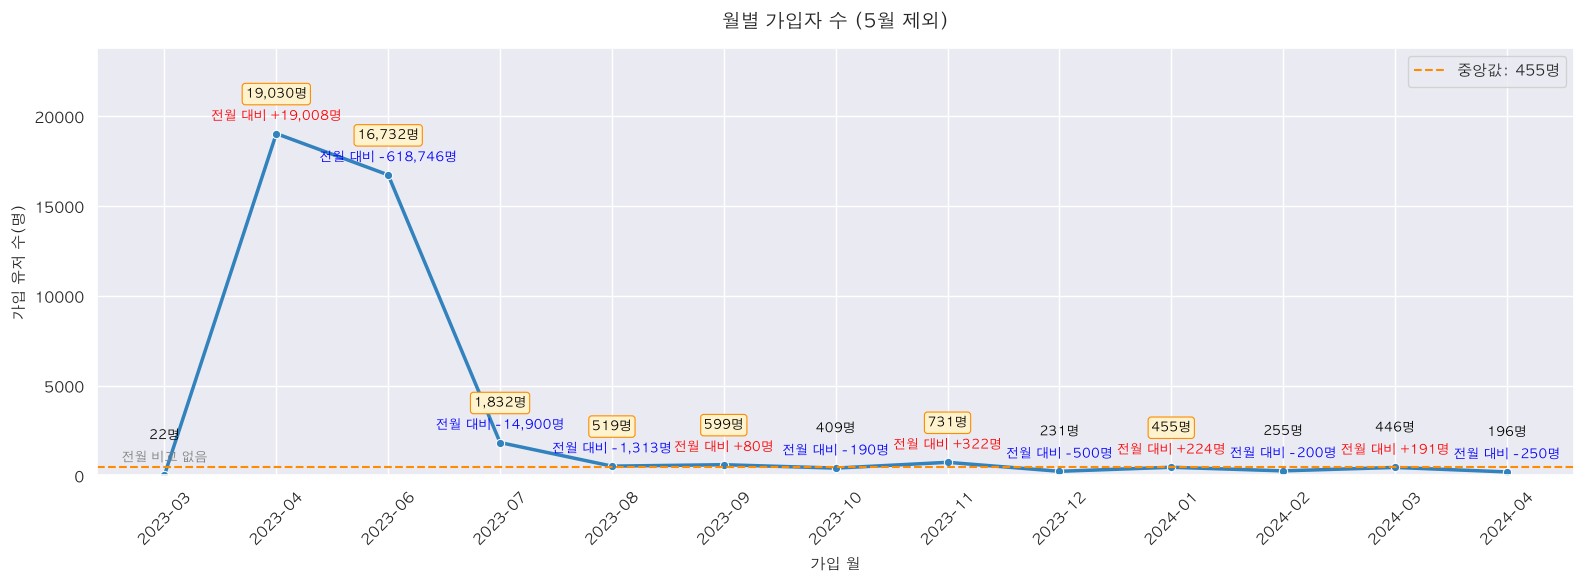

In [57]:
plot_monthly_signups(monthly_summary_ex_may, '월별 가입자 수 (5월 제외)')

### 월별 가입자 추이

* **가입자 수가 다른 월 대비 두드러지게 높은 시기**: 2023년 4월, 5월, 6월
* **전월 대비 가입자 수가 증가한 달**: 2023년 4월, 5월, 9월, 11월 / 2024년 1월, 3월
* **가입자 수가 전체 기간 중앙값 이상인 달**: 2023년 4월~9월, 11월 / 2024년 1월

### 학사일정과의 연관성

* 서비스 초기인 **2023년 4~6월의 높은 가입자 수는 서비스 출시 초기 효과의 영향을 받았을 가능성**이 있어, 학사일정만으로 해당 증가세를 설명하기에는 한계가 있습니다.
* 따라서 초기 효과가 완화되고 **가입자 유입이 비교적 안정화된 시점부터 학사일정과 가입자 수 변화를 비교**하여 유입 패턴과의 연관성을 확인하고자 합니다.
* 학교별 세부 학사일정은 학교장의 재량에 따라 차이가 있으므로, 본 분석에서는 **일반적이고 보편적인 학사일정을 기준**으로 비교합니다.

---

### 일반적인 학사 일정

| 시기 | 일반적인 학사 일정 |
|---|---|
| **3월 초** | 입학식·시업식, 새 학년 시작 |
| **3~4월** | 정규수업, 학급·동아리 활동 시작 |
| **4월 말~5월 초** | 1학기 중간고사 |
| **5월** | 중간고사 이후 수업, 체육대회·체험활동 등 |
| **6월 말~7월 초** | 1학기 기말고사 |
| **7월 중·하순~8월 중·하순** | 여름방학, 이후 개학 |
| **8월 중·하순~9월** | 2학기 수업 시작 |
| **9월 말~10월** | 2학기 중간고사 |
| **10~11월** | 정규수업, 수학여행·체험활동 등 |
| **11월** | 대학수학능력시험 |
| **12월** | 2학기 기말고사, 학년말 활동 |
| **12월 말~2월** | 겨울방학, 종업·졸업, 학년말 방학 |

## 중학교 / 고등학교 유저 수 비교

In [58]:
school_summary = (
    df.groupby('school_type')['user_id']
      .nunique()
      .reset_index(name='unique_users')
)

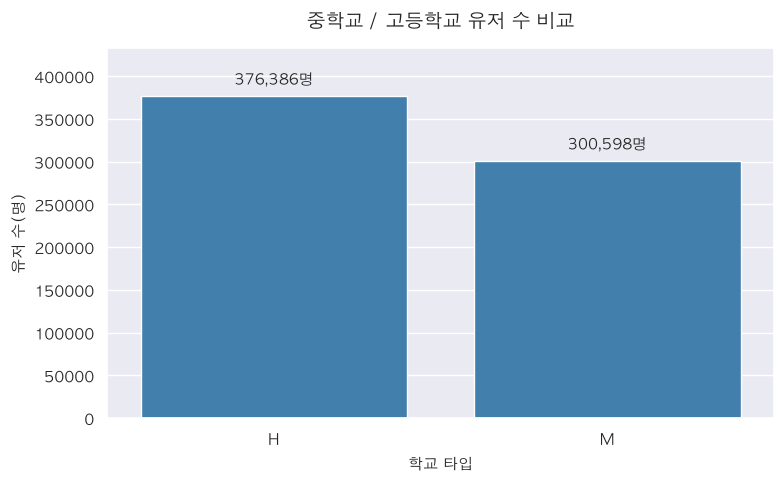

In [59]:
plt.figure(figsize=(8, 5))

# 막대그래프
ax = sns.barplot(
    data=school_summary,
    x='school_type',
    y='unique_users',
    color='#3182bd'
)

# 막대 위에 숫자 표시
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height):,}명',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=11,
    )

plt.title('중학교 / 고등학교 유저 수 비교', fontsize=14, pad=15)
plt.xlabel('학교 타입', fontsize=11)
plt.ylabel('유저 수(명)', fontsize=11)

# 위쪽 숫자가 잘리지 않도록 여유 공간
plt.ylim(0, school_summary['unique_users'].max() * 1.15)

plt.tight_layout()
plt.show()

In [60]:
# 학교급·학년별 고유 가입자 수 집계
school_grade_summary = (
    df.groupby(['school_type', 'grade'])['user_id']
      .nunique()
      .reset_index(name='unique_users')
)


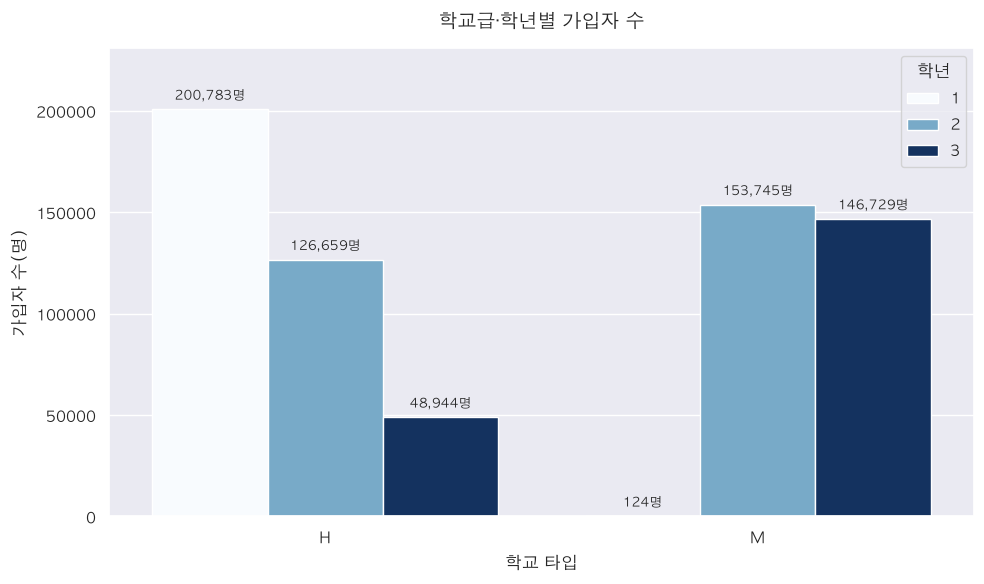

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=school_grade_summary,
    x='school_type',
    y='unique_users',
    hue='grade',
    palette='Blues',
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{value:,.0f}명' for value in container.datavalues],
        padding=4,
        fontsize=9,
    )

ax.set_title('학교급·학년별 가입자 수', fontsize=14, pad=15)
ax.set_xlabel('학교 타입')
ax.set_ylabel('가입자 수(명)')
ax.legend(title='학년')
ax.set_ylim(0, school_grade_summary['unique_users'].max() * 1.15)

fig.tight_layout()
plt.show()


* 가입된 유저의 분포를 확인해 본 결과 중학교 2학년 ~ 고등학교 2학년까지 가장 많은 비중을 차지하고 있다.

## 도시 별 유저 수 비교

In [62]:
# 학교 소재지 기준: 주소 공백 정리 및 지역 구분
area_df = df.copy()

address = (
    area_df['address']
    .astype('string')
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .replace({'-': pd.NA, '': pd.NA})
)

parts = address.str.split(n=2, expand=True)

area_df['시도'] = parts[0].fillna('미상')
area_df['시군구'] = parts.reindex(columns=[1])[1].fillna('미기재')

# 시·도별 고유 가입자 수
region_summary = (
    area_df.groupby('시도')['user_id']
    .nunique()
    .reset_index(name='가입자 수')
    .sort_values('가입자 수', ascending=False)
)

# 시·도 + 시·군·구별 고유 가입자 수
city_summary = (
    area_df.groupby(['시도', '시군구'])['user_id']
    .nunique()
    .reset_index(name='가입자 수')
    .sort_values('가입자 수', ascending=False)
)

# 전체 고유 가입자 대비 지역별 비중
total_users = area_df['user_id'].nunique()

region_summary['비중(%)'] = (
    region_summary['가입자 수'] / total_users * 100
).round(2)

city_summary['비중(%)'] = (
    city_summary['가입자 수'] / total_users * 100
).round(2)

display(region_summary)
display(city_summary)


,시도,가입자 수,비중(%)
1,경기도,191707,28.32
8,서울특별시,74521,11.01
14,충청남도,42776,6.32
2,경상남도,41893,6.19
10,인천광역시,41286,6.10
7,부산광역시,41087,6.07
5,대구광역시,35147,5.19
12,전라북도,34448,5.09
11,전라남도,31571,4.66
3,경상북도,30265,4.47


,시도,시군구,가입자 수,비중(%)
30,경기도,수원시,19764,2.92
19,경기도,고양시,17530,2.59
40,경기도,용인시,17524,2.59
48,경기도,화성시,16957,2.50
197,전라북도,전주시,13492,1.99
...,...,...,...,...
220,충청북도,보은군,49,0.01
10,강원도,정선군,46,0.01
83,경상북도,울릉군,27,0.00
162,인천광역시,옹진군,24,0.00


In [63]:
def plot_area_signups(data, label_col, title):
    fig, ax = plt.subplots(
        figsize=(12, max(5, len(data) * 0.4))
    )

    bars = ax.barh(
        data[label_col],
        data['가입자 수'],
        color='#3182bd',
    )

    ax.bar_label(
        bars,
        labels=[
            f'{count:,.0f}명 ({share:.2f}%)'
            for count, share in zip(data['가입자 수'], data['비중(%)'])
        ],
        padding=5,
        fontsize=9,
    )

    ax.invert_yaxis()
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('가입자 수(명)')
    ax.set_ylabel('')
    ax.set_xlim(0, data['가입자 수'].max() * 1.35)

    fig.tight_layout()
    plt.show()


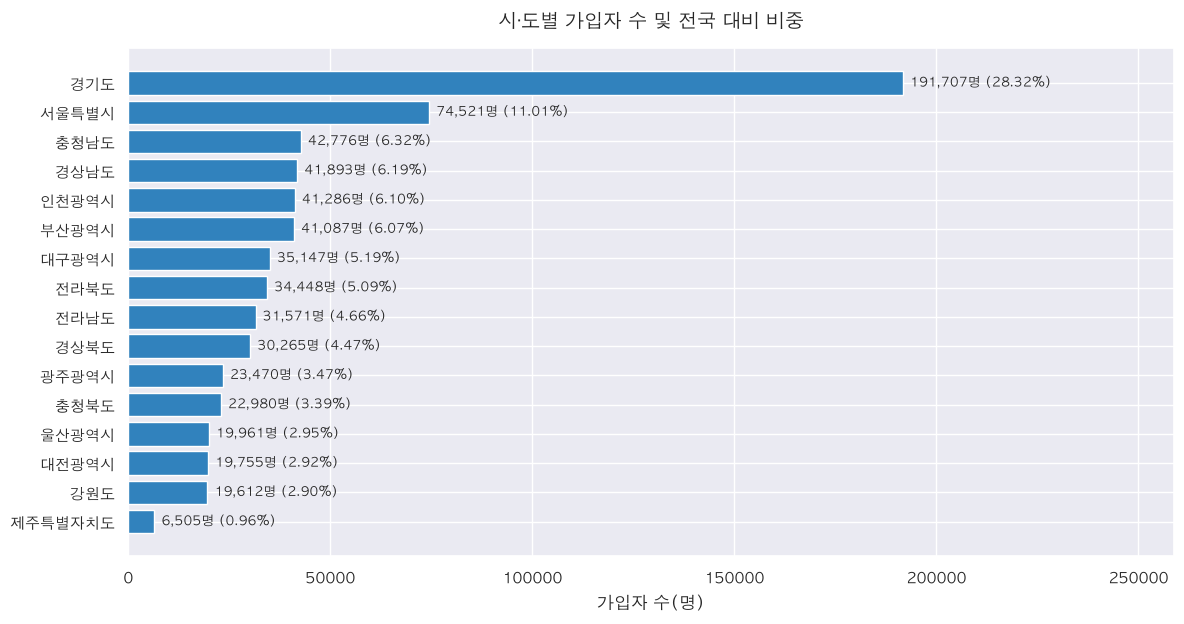

In [64]:
plot_area_signups(
    region_summary.sort_values('가입자 수', ascending=False),
    '시도',
    '시·도별 가입자 수 및 전국 대비 비중',
)


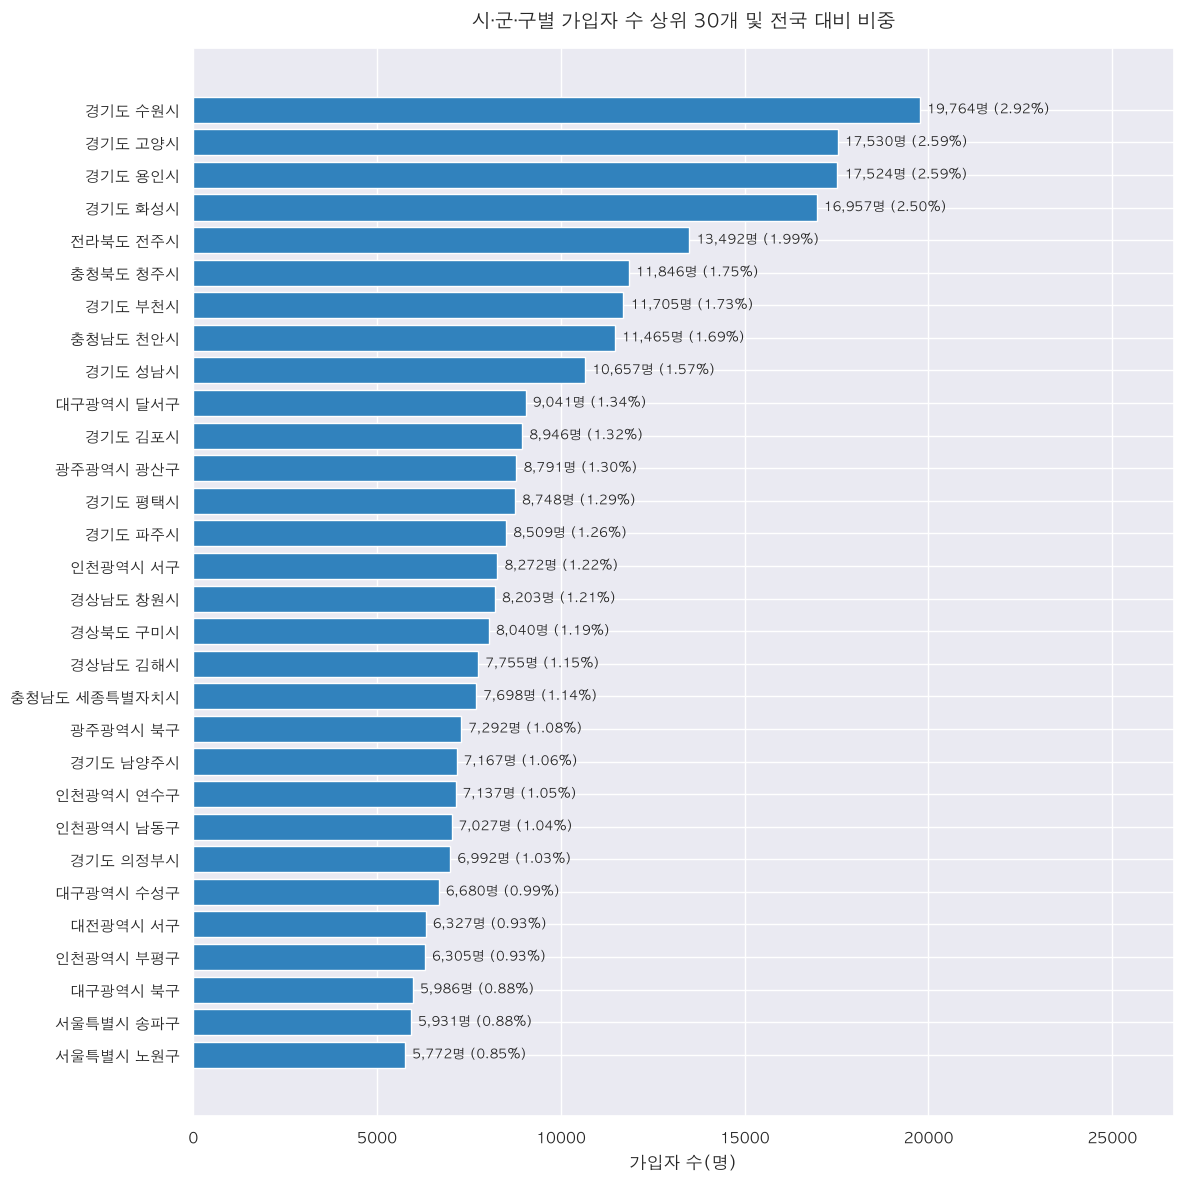

In [65]:
city_top30 = (
    city_summary.nlargest(30, '가입자 수')
    .copy()
)

city_top30['지역'] = city_top30['시도'] + ' ' + city_top30['시군구']

plot_area_signups(
    city_top30,
    '지역',
    '시·군·구별 가입자 수 상위 30개 및 전국 대비 비중',
)


### 지역별 가입자 분포

- **경기도**는 전체 가입자의 약 **28%**를 차지하며, 가장 많은 가입자가 분포한 지역이다.
- 그다음으로 **서울(약 11%)**이 높은 비중을 차지하며, 충청남도, 경상남도, 인천, 부산, 대구 순으로 이어진다.
- 다만 **시·군·구 단위**로 세분화하면 다른 양상이 나타난다. 서울에 속한 개별 행정구는 가입자 수 기준 상위권에서 상대적으로 적게 나타난다.
- 이를 통해 서울은 **특정 행정구에 가입자가 집중되기보다는 여러 행정구에 비교적 고르게 분포**되어 있을 가능성을 생각해볼 수 있다.

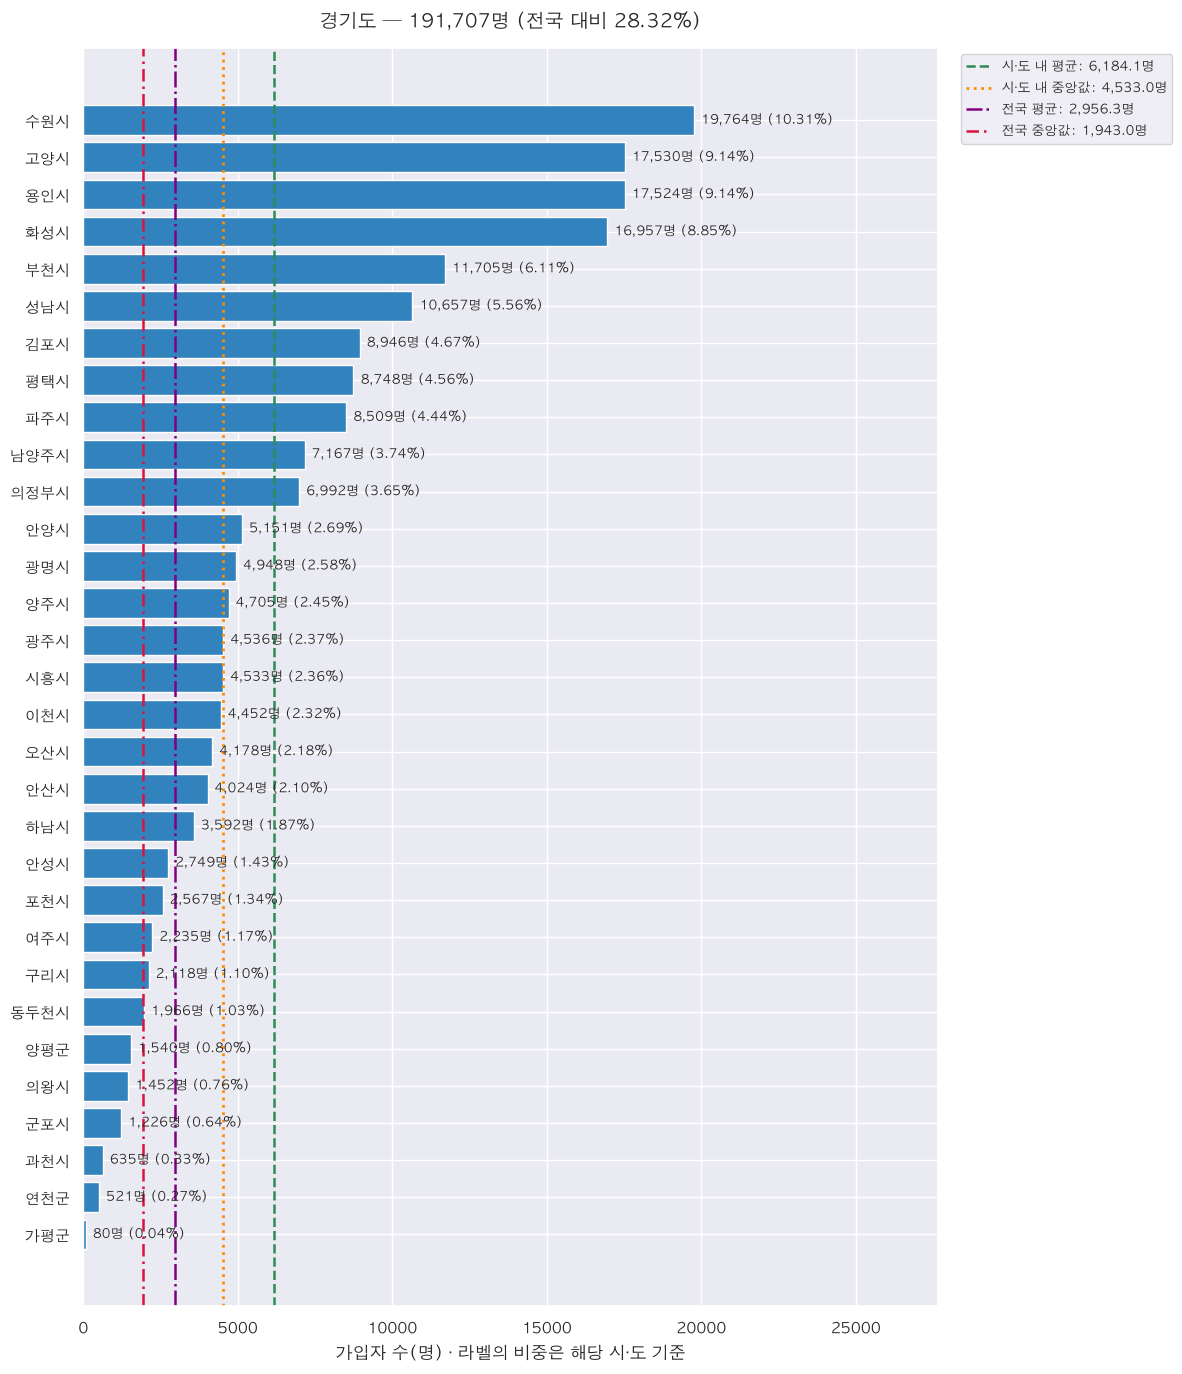

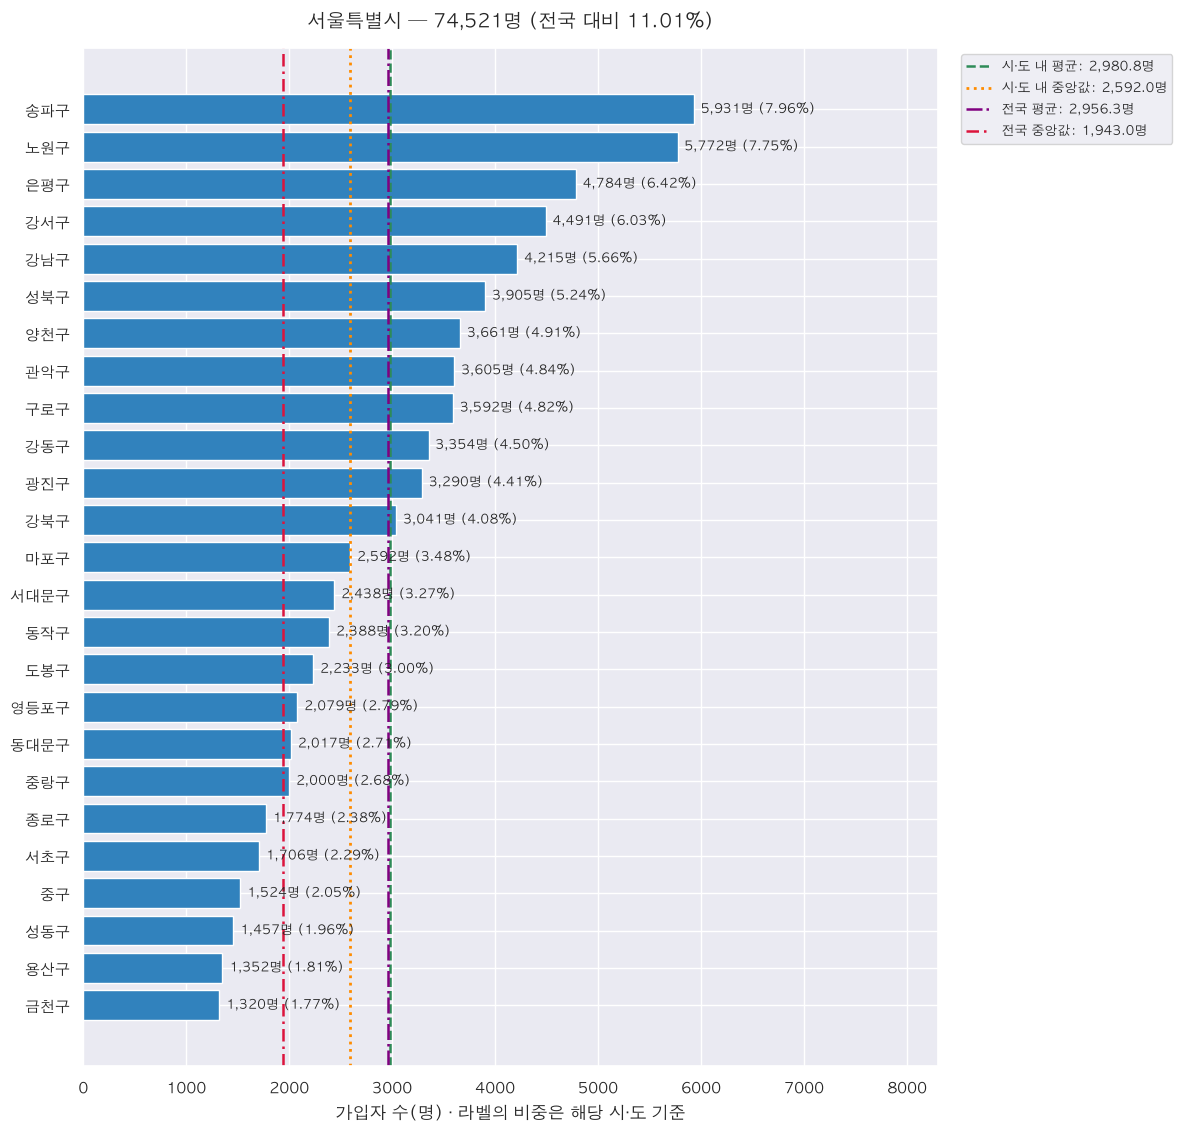

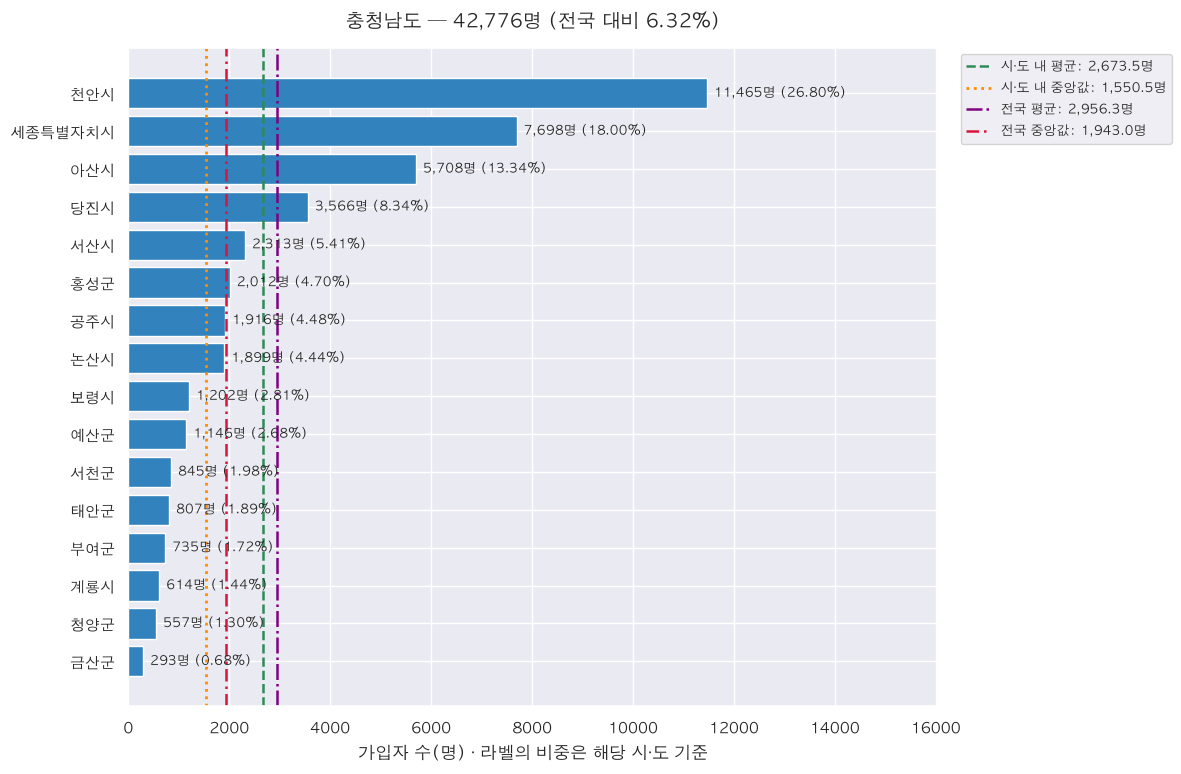

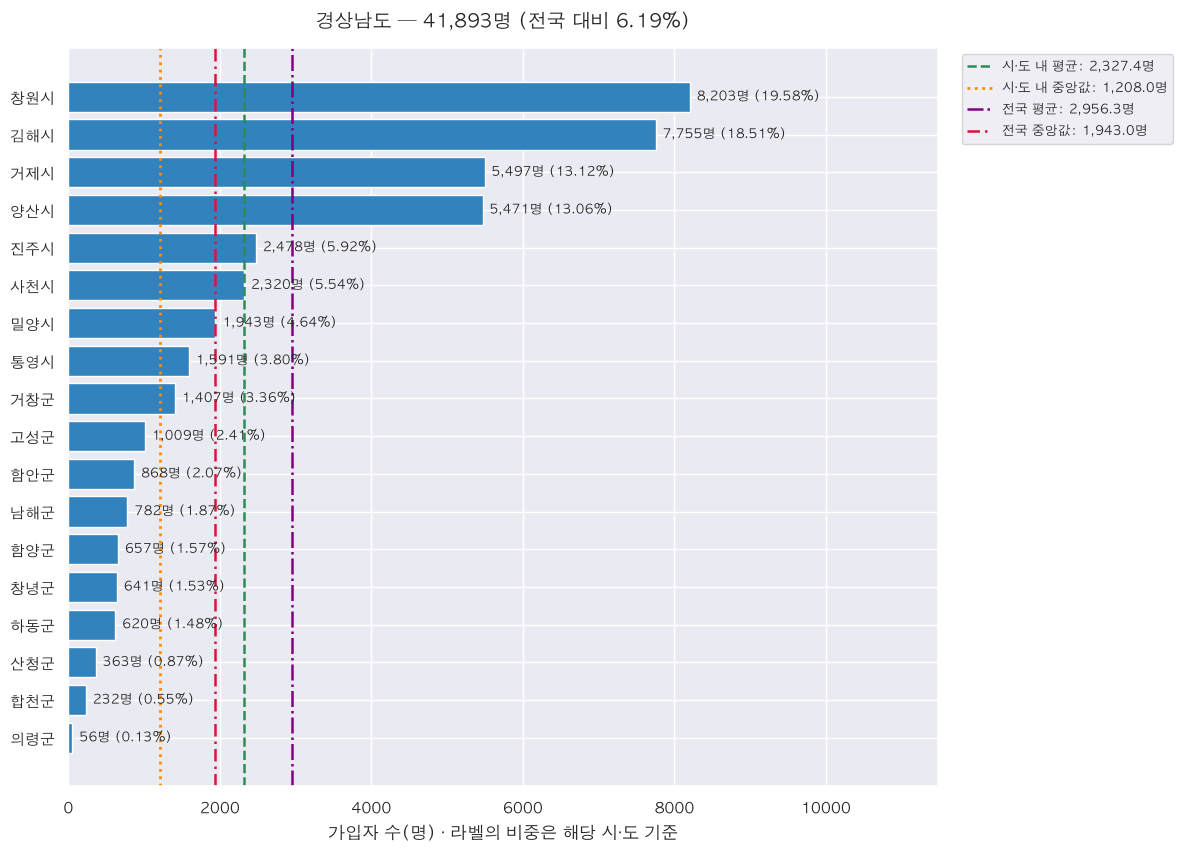

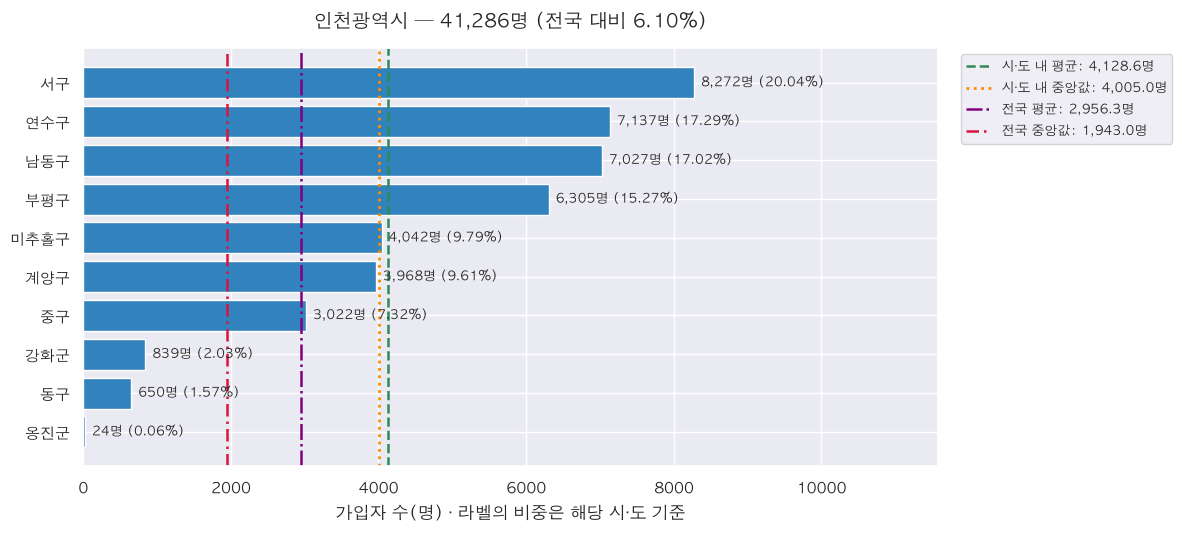

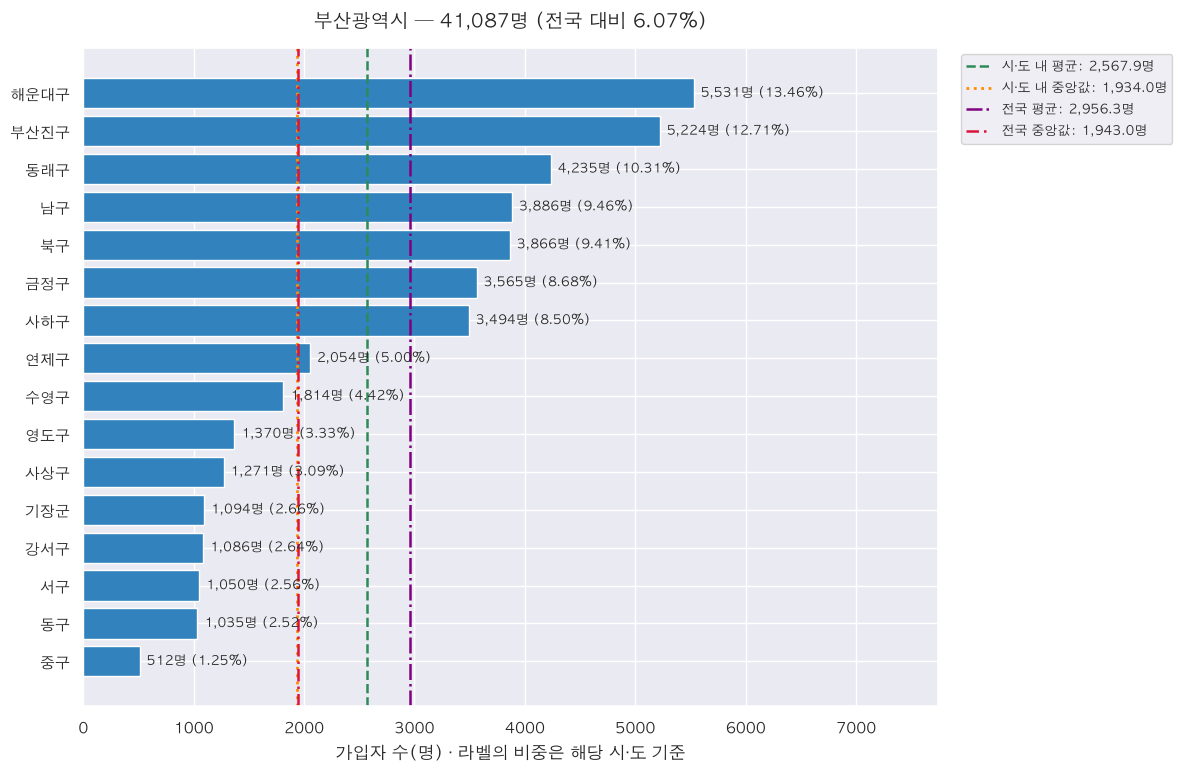

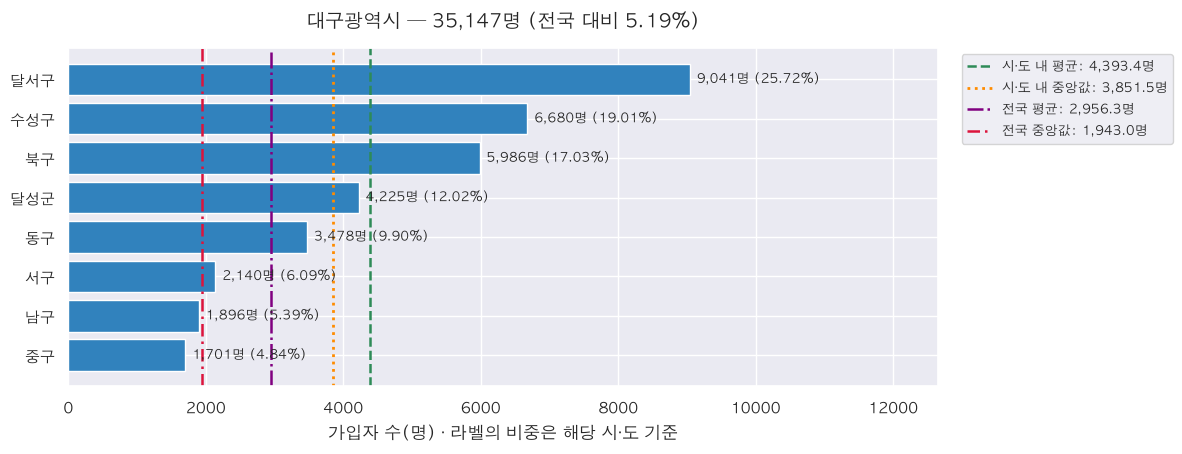

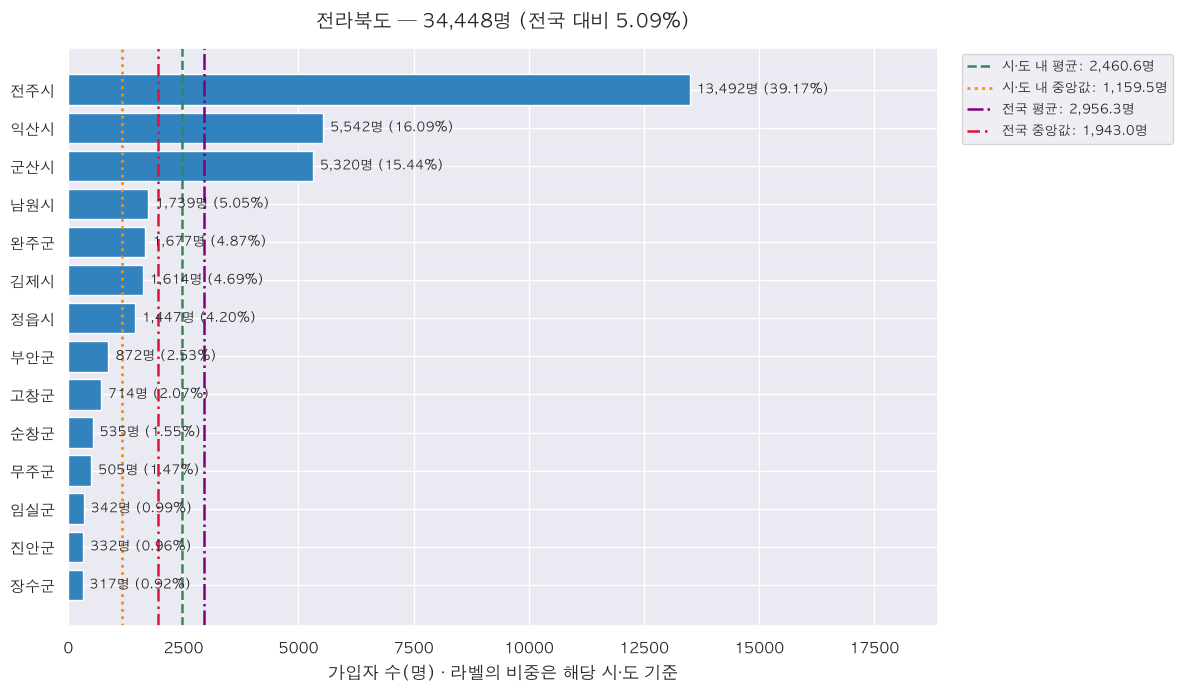

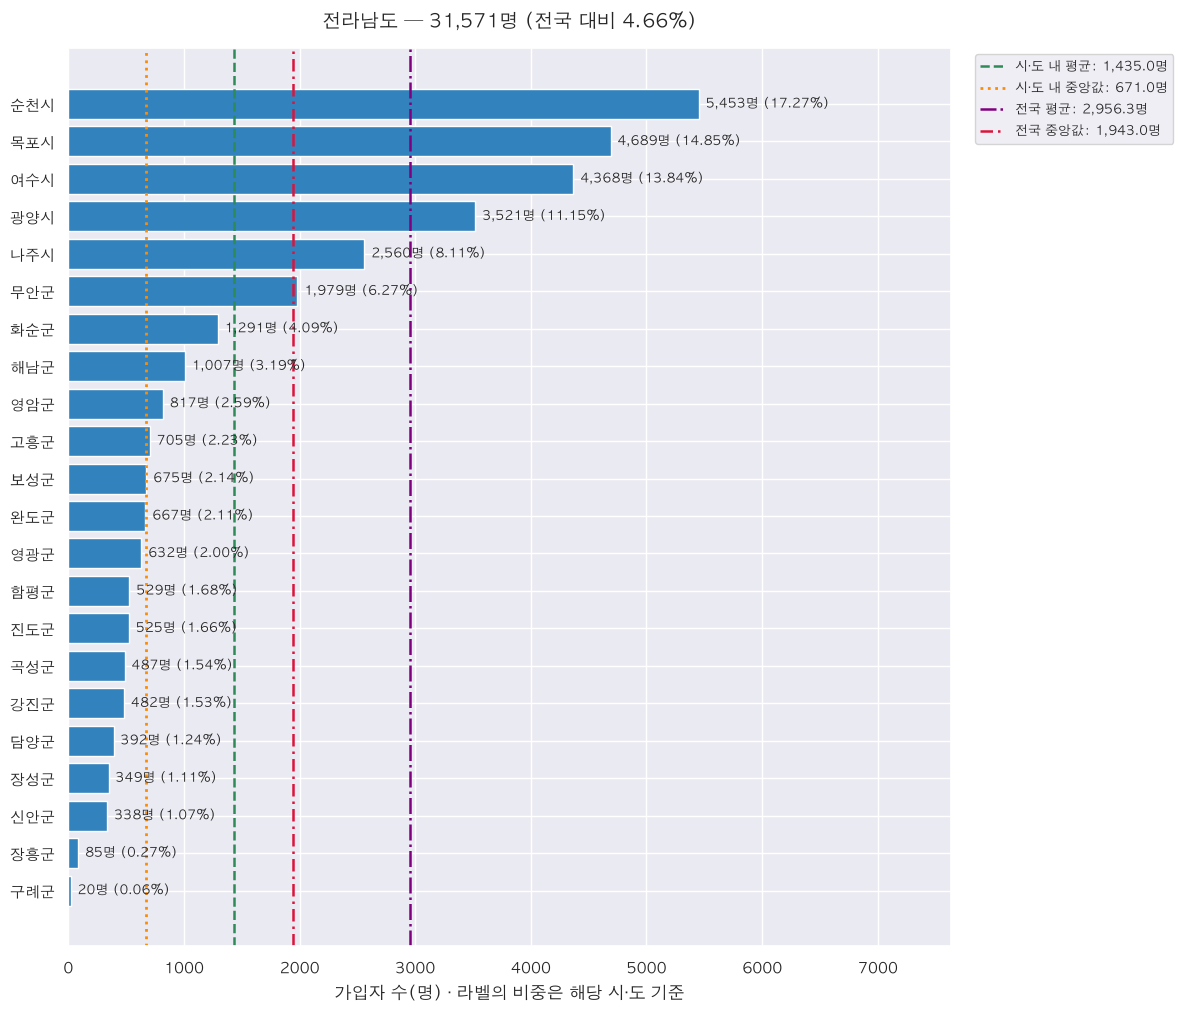

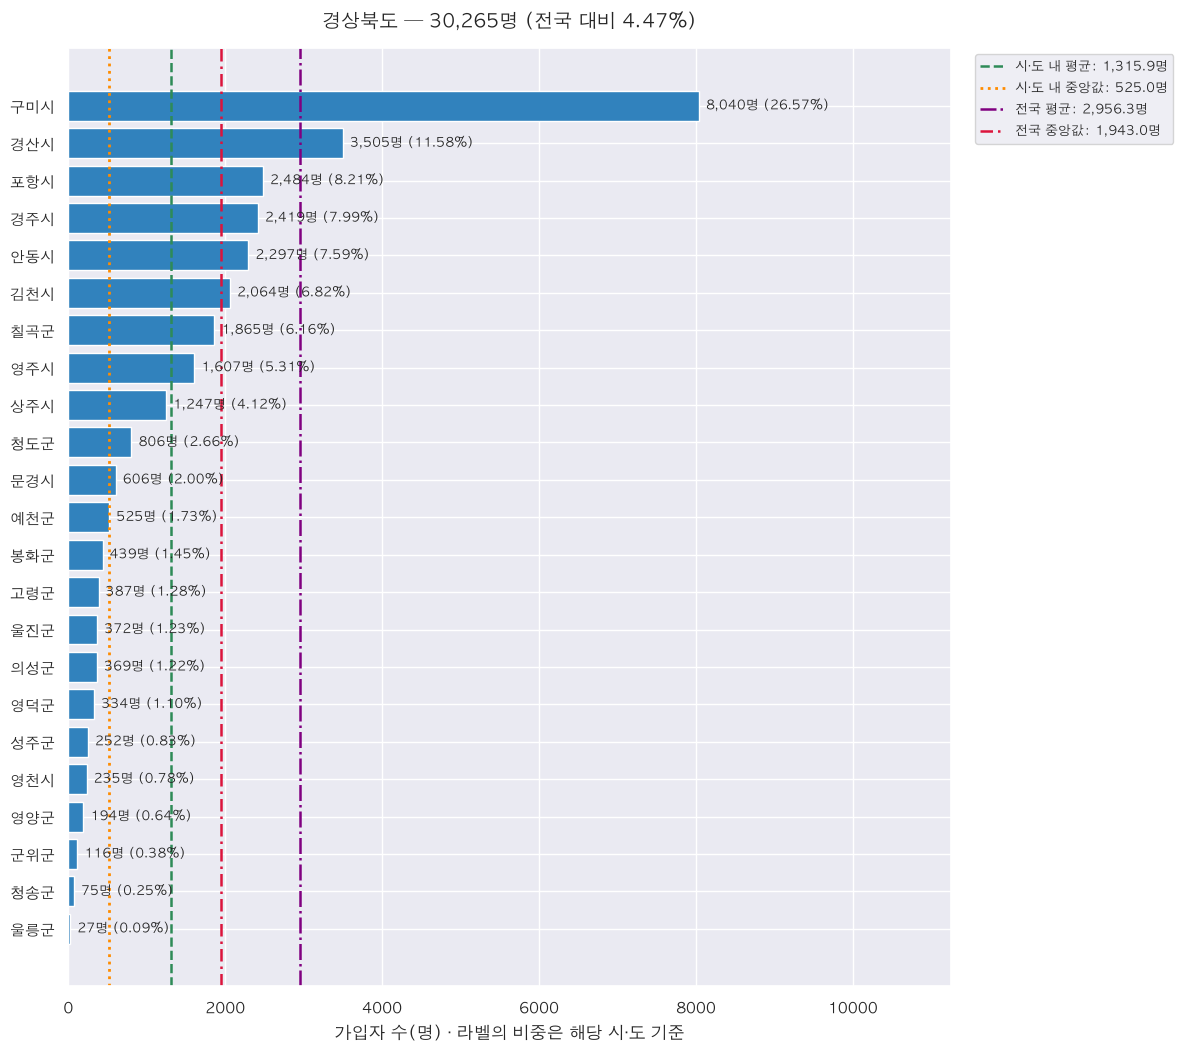

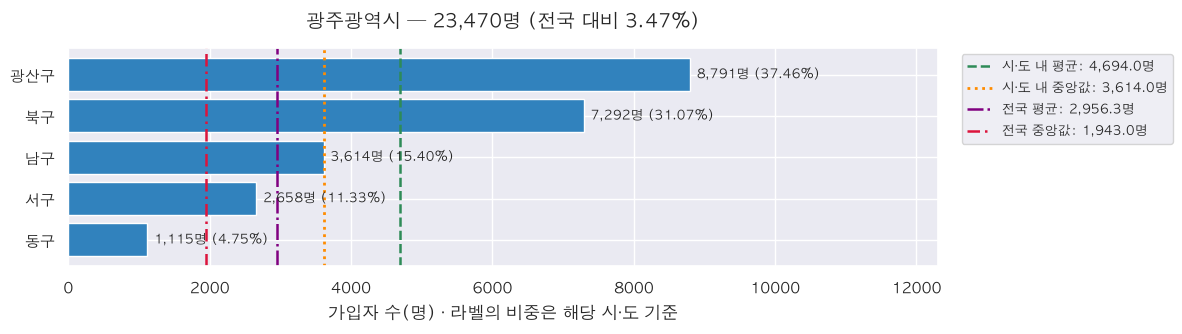

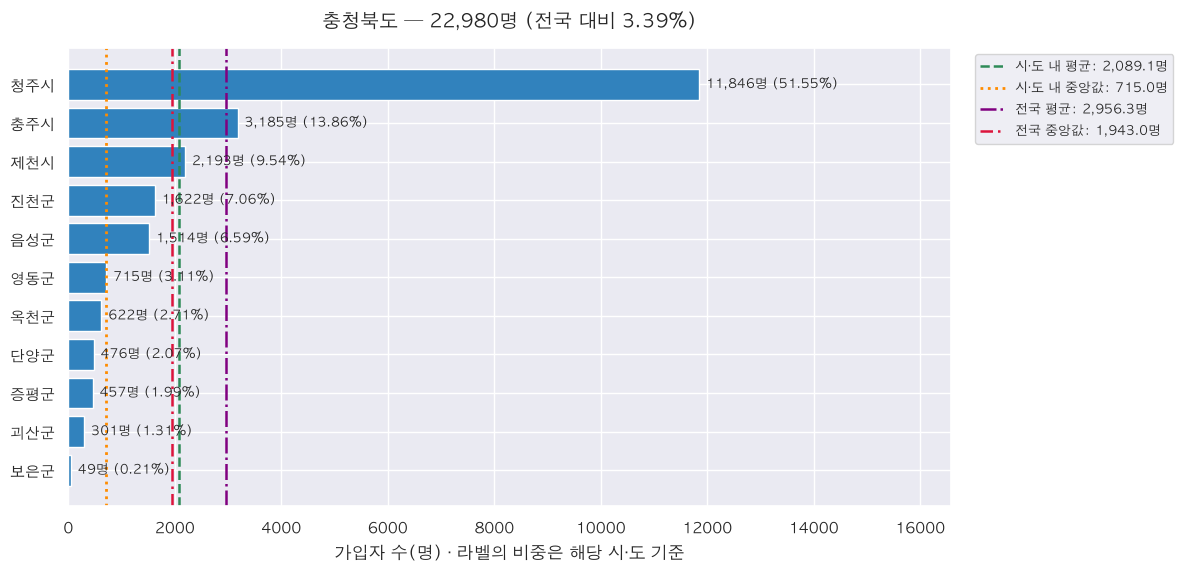

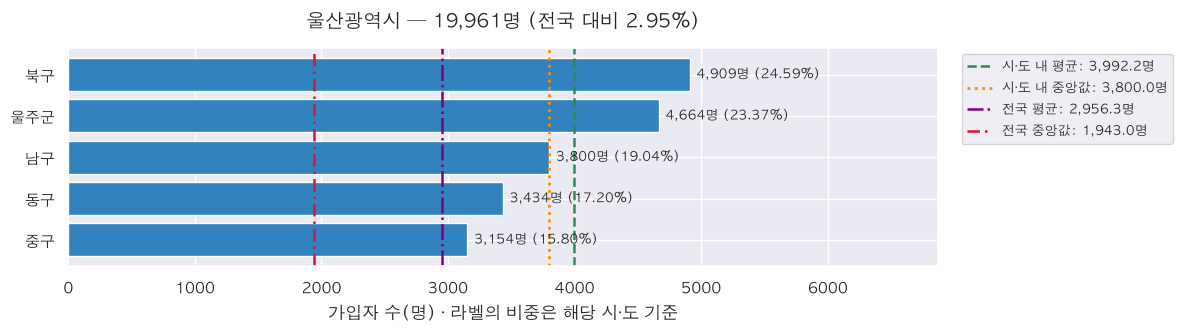

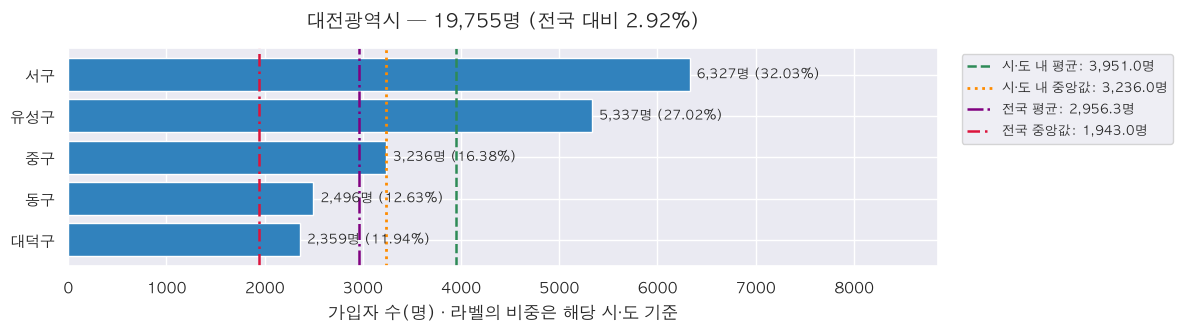

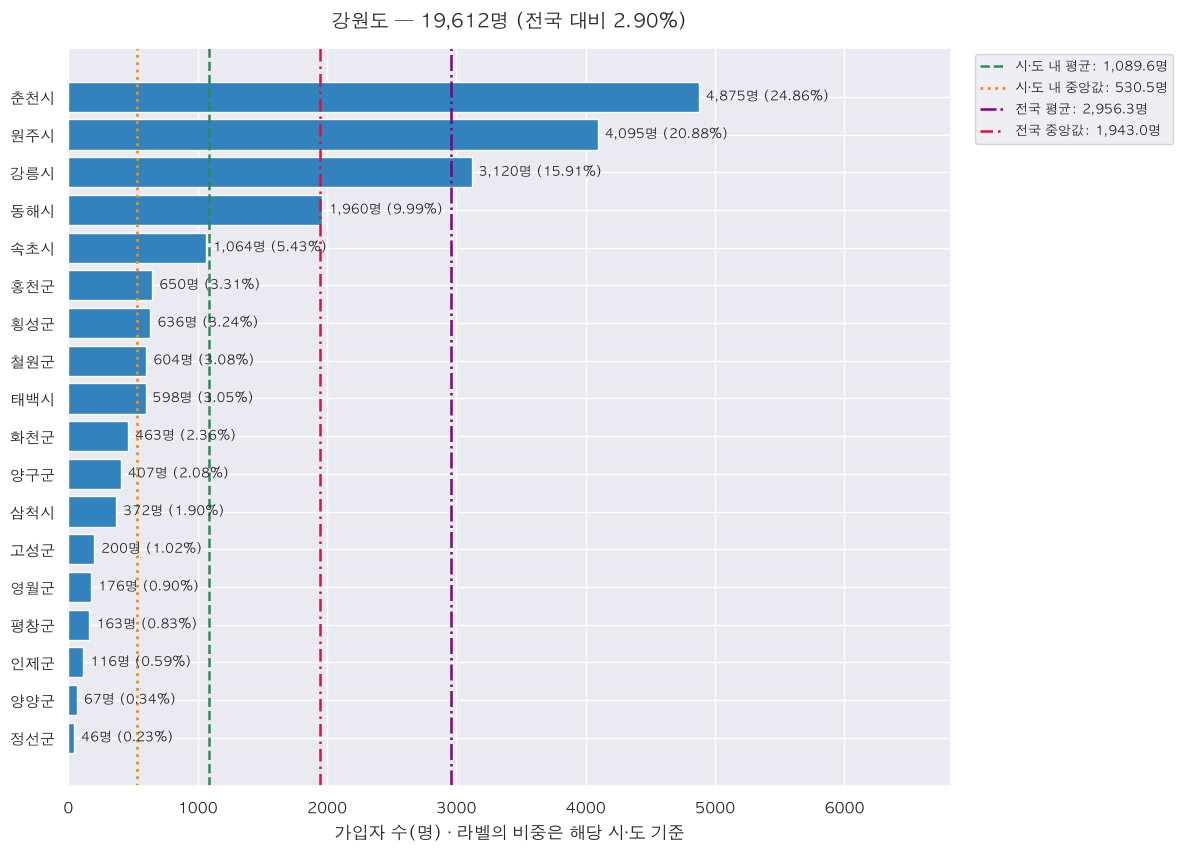

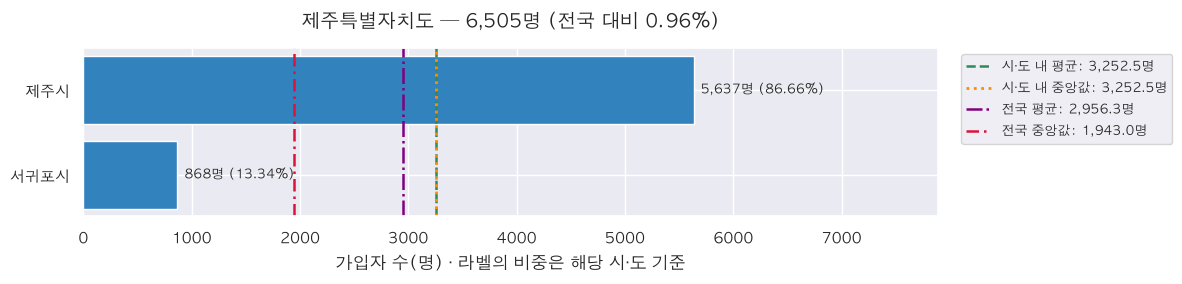

In [66]:
# 전국 기준은 현재 city_summary에 포함된 전체 시·군·구입니다.
national_mean_users = city_summary['가입자 수'].mean()
national_median_users = city_summary['가입자 수'].median()

# 시·도별 하위 시·군·구 가입자 분포
# 제목의 비중은 전국 기준, 막대 라벨의 비중은 해당 시·도 기준입니다.
for _, region in region_summary.sort_values('가입자 수', ascending=False).iterrows():
    region_name = region['시도']
    region_users = region['가입자 수']

    region_cities = (
        city_summary.loc[city_summary['시도'].eq(region_name)]
        .sort_values('가입자 수', ascending=False)
        .copy()
    )
    if region_cities.empty:
        continue

    region_cities['시도 내 비중(%)'] = (
        region_cities['가입자 수'] / region_users * 100
        if region_users > 0 else 0.0
    )

    fig, ax = plt.subplots(
        figsize=(12, max(3, len(region_cities) * 0.4 + 1.5))
    )
    bars = ax.barh(
        region_cities['시군구'],
        region_cities['가입자 수'],
        color='#3182bd',
    )
    ax.bar_label(
        bars,
        labels=[
            f'{count:,.0f}명 ({share:.2f}%)'
            for count, share in zip(
                region_cities['가입자 수'],
                region_cities['시도 내 비중(%)'],
            )
        ],
        padding=5,
        fontsize=9,
    )

    # 해당 시·도에 표시된 시·군·구별 가입자 수의 평균과 중앙값
    mean_users = region_cities['가입자 수'].mean()
    median_users = region_cities['가입자 수'].median()

    ax.axvline(
        x=mean_users,
        color='seagreen',
        linestyle='--',
        linewidth=1.8,
        label=f'시·도 내 평균: {mean_users:,.1f}명',
    )
    ax.axvline(
        x=median_users,
        color='darkorange',
        linestyle=':',
        linewidth=2,
        label=f'시·도 내 중앙값: {median_users:,.1f}명',
    )
    ax.axvline(
        x=national_mean_users,
        color='purple',
        linestyle='-.',
        linewidth=1.8,
        label=f'전국 평균: {national_mean_users:,.1f}명',
    )
    ax.axvline(
        x=national_median_users,
        color='crimson',
        linestyle=(0, (5, 2, 1, 2)),
        linewidth=1.8,
        label=f'전국 중앙값: {national_median_users:,.1f}명',
    )
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)

    ax.invert_yaxis()
    ax.set_title(
        f"{region_name} — {region_users:,.0f}명 (전국 대비 {region['비중(%)']:.2f}%)",
        fontsize=14,
        pad=15,
    )
    ax.set_xlabel('가입자 수(명) · 라벨의 비중은 해당 시·도 기준')
    ax.set_ylabel('')
    # 전국 기준선도 축 범위 안에 포함
    ax.set_xlim(0, max(
        1,
        region_cities['가입자 수'].max() * 1.4,
        national_mean_users * 1.1,
        national_median_users * 1.1,
    ))

    fig.tight_layout()
    plt.show()
    plt.close(fig)


In [67]:
# 전체 시·군·구별 가입자 수의 평균과 중앙값
# 시·도별 평균의 평균이 아니라, city_summary 전체 행을 기준으로 계산합니다.
overall_area_summary = pd.DataFrame([{
    '기준': '전체 시·군·구 (현재 집계 기준)',
    '시군구수': len(city_summary),
    '평균': city_summary['가입자 수'].mean(),
    '중앙값': city_summary['가입자 수'].median(),
}])

display(
    overall_area_summary.style.format(
        {'평균': '{:,.1f}', '중앙값': '{:,.1f}'}
    )
)

# 시·도 내 시·군·구별 가입자 수의 표준편차가 작은 순서
# 현재 집계에 포함된 지역 기준이며, 가입자가 없는 미관측 지역은 포함하지 않습니다.
region_dispersion = (
    city_summary.groupby('시도')['가입자 수']
    .agg(
        시군구수='size',
        평균='mean',
        중앙값='median',
        표준편차=lambda values: values.std(ddof=0),
    )
    .reset_index()
)

# 비교 대상이 하나뿐인 지역은 순위를 매기지 않습니다.
comparable = region_dispersion['시군구수'].ge(2)
region_dispersion.loc[~comparable, '표준편차'] = float('nan')
region_dispersion['순위'] = (
    region_dispersion['표준편차'].rank(method='min').astype('Int64')
)
region_dispersion = (
    region_dispersion.sort_values(['표준편차', '시도'], na_position='last')
    [['순위', '시도', '시군구수', '평균', '중앙값', '표준편차']]
    .reset_index(drop=True)
)

display(
    region_dispersion.style.format(
        {'평균': '{:,.1f}', '중앙값': '{:,.1f}', '표준편차': '{:,.1f}'},
        na_rep='비교 제외',
    )
)



,기준,시군구수,평균,중앙값
0,전체 시·군·구 (현재 집계 기준),229,"2,956.3","1,943.0"


,순위,시도,시군구수,평균,중앙값,표준편차
0,1,울산광역시,5,"3,992.2","3,800.0",684.5
1,2,서울특별시,25,"2,980.8","2,592.0","1,309.4"
2,3,강원도,18,"1,089.6",530.5,"1,415.4"
3,4,전라남도,22,"1,435.0",671.0,"1,580.1"
4,5,대전광역시,5,"3,951.0","3,236.0","1,595.6"
5,6,부산광역시,16,"2,567.9","1,934.0","1,602.5"
6,7,경상북도,23,"1,315.9",525.0,"1,725.4"
7,8,제주특별자치도,2,"3,252.5","3,252.5","2,384.5"
8,9,대구광역시,8,"4,393.4","3,851.5","2,469.7"
9,10,경상남도,18,"2,327.4","1,208.0","2,513.1"


* 각 시도 단위의 표준편차를 나열해 본 결과 서울 지역의 표준편차가 2위를 차지하면서 (오름차순 기준)
위 가설을 직접적으로 확인할 수 있었다.
* 또한 상대적으로 많은 지역구와 생활인구로 인하여 가입자 수2위에 있음을 확인할 수 있었다.
* 그에 반해 경기도 지역은 편차가 매우 큰 편이었으나 많은 행정 구역이 ...

## 집단 가입 패턴 및 확산 속도 분석

* 기록된 `group_id`가 가입 당시에도 동일했다고 가정하며, 학급 변동은 고려하지 않습니다.
* 기존 가입 시각과 시간대를 그대로 사용합니다.
* 고유 가입자 10명 이상인 그룹에서 연속 24시간 최대 가입 인원과 집중도를 계산합니다.
* 집중도는 그룹의 관측 가입자 수 대비 비중이며, 실제 학급 정원 대비 가입률이 아닙니다.
* 구간은 시작 시각 이상, 종료 시각 미만입니다. 동률이면 가장 이른 구간을 선택합니다.
* 10명과 24시간은 탐색 기준이며, 결과만으로 초대나 입소문 등 가입 원인을 확정하지 않습니다.


In [68]:
MIN_GROUP_USERS = 10
WINDOW_HOURS = 24

group_signups = df[['user_id', 'group_id', 'signup_date']].copy()

# 가입 시각을 변환하지 않고 기존 datetime 컬럼을 그대로 사용
if not pd.api.types.is_datetime64_any_dtype(group_signups['signup_date'].dtype):
    raise TypeError('signup_date가 datetime 형식인지 확인해 주세요. 시간 변환은 수행하지 않습니다.')

invalid_rows = group_signups[
    ['user_id', 'group_id', 'signup_date']
].isna().any(axis=1)
print(f'필수 값 누락으로 제외한 행: {invalid_rows.sum():,}개')

group_signups = (
    group_signups.loc[~invalid_rows]
    .sort_values('signup_date')
    .drop_duplicates(['group_id', 'user_id'], keep='first')
)

group_sizes = group_signups.groupby('group_id')['user_id'].nunique()
eligible_groups = group_sizes[group_sizes >= MIN_GROUP_USERS].index
analysis_signups = group_signups[
    group_signups['group_id'].isin(eligible_groups)
].copy()

coverage = pd.DataFrame({
    '구분': ['전체 유효 그룹', '분석 대상 그룹', f'{MIN_GROUP_USERS}명 미만 제외 그룹'],
    '그룹 수': [
        len(group_sizes), len(eligible_groups),
        (group_sizes < MIN_GROUP_USERS).sum(),
    ],
})
display(coverage)
print(
    f'분석 대상 고유 가입자: {analysis_signups["user_id"].nunique():,}명 / '
    f'전체 유효 고유 가입자: {group_signups["user_id"].nunique():,}명'
)


필수 값 누락으로 제외한 행: 0개


,구분,그룹 수
0,전체 유효 그룹,80891
1,분석 대상 그룹,33615
2,10명 미만 제외 그룹,47276


분석 대상 고유 가입자: 485,101명 / 전체 유효 고유 가입자: 676,984명


In [69]:
def summarize_group_burst(group, window_hours=24):
    times = group['signup_date'].sort_values().reset_index(drop=True)
    window = pd.Timedelta(hours=window_hours)
    right = 0
    best_left = 0
    best_count = 0

    for left in range(len(times)):
        while right < len(times) and times.iloc[right] < times.iloc[left] + window:
            right += 1
        count = right - left
        if count > best_count:
            best_left = left
            best_count = count

    start = times.iloc[best_left]
    return {
        '가입자 수': len(times),
        '최대 구간 가입자 수': best_count,
        '가입 집중도(%)': best_count / len(times) * 100,
        '집중 구간 시작': start,
        '집중 구간 종료(미포함)': start + window,
        '그룹 최초 가입': times.iloc[0],
        '그룹 최종 가입': times.iloc[-1],
    }


records = []
for group_id, group in analysis_signups.groupby('group_id'):
    records.append({
        'group_id': group_id,
        **summarize_group_burst(group, WINDOW_HOURS),
    })

burst_columns = [
    'group_id', '가입자 수', '최대 구간 가입자 수', '가입 집중도(%)',
    '집중 구간 시작', '집중 구간 종료(미포함)',
    '그룹 최초 가입', '그룹 최종 가입',
]
group_burst_summary = (
    pd.DataFrame(records, columns=burst_columns)
    .sort_values(
        ['가입 집중도(%)', '최대 구간 가입자 수'],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)
display(group_burst_summary.head(30).style.format({'가입 집중도(%)': '{:.1f}'}))


,group_id,가입자 수,최대 구간 가입자 수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),그룹 최초 가입,그룹 최종 가입
0,43124,24,24,100.0,2023-05-11 01:12:49.669935+00:00,2023-05-12 01:12:49.669935+00:00,2023-05-11 01:12:49.669935+00:00,2023-05-12 00:57:01.749899+00:00
1,38756,22,22,100.0,2023-05-17 01:11:49.634726+00:00,2023-05-18 01:11:49.634726+00:00,2023-05-17 01:11:49.634726+00:00,2023-05-17 11:06:57.134108+00:00
2,41875,22,22,100.0,2023-05-10 11:32:11.607936+00:00,2023-05-11 11:32:11.607936+00:00,2023-05-10 11:32:11.607936+00:00,2023-05-11 09:36:33.179702+00:00
3,52751,21,21,100.0,2023-05-13 03:44:50.520752+00:00,2023-05-14 03:44:50.520752+00:00,2023-05-13 03:44:50.520752+00:00,2023-05-13 16:23:17.516385+00:00
4,11500,20,20,100.0,2023-05-06 11:26:30.975532+00:00,2023-05-07 11:26:30.975532+00:00,2023-05-06 11:26:30.975532+00:00,2023-05-07 08:18:16.258602+00:00
5,45232,20,20,100.0,2023-05-11 06:55:11.208412+00:00,2023-05-12 06:55:11.208412+00:00,2023-05-11 06:55:11.208412+00:00,2023-05-12 04:28:12.414366+00:00
6,47196,20,20,100.0,2023-05-11 14:14:02.380379+00:00,2023-05-12 14:14:02.380379+00:00,2023-05-11 14:14:02.380379+00:00,2023-05-12 09:42:22.709307+00:00
7,41482,19,19,100.0,2023-05-10 10:12:55.899769+00:00,2023-05-11 10:12:55.899769+00:00,2023-05-10 10:12:55.899769+00:00,2023-05-11 05:45:44.502754+00:00
8,42870,19,19,100.0,2023-05-10 13:28:44.092057+00:00,2023-05-11 13:28:44.092057+00:00,2023-05-10 13:28:44.092057+00:00,2023-05-11 02:03:07.618733+00:00
9,52840,19,19,100.0,2023-05-13 04:03:40.194088+00:00,2023-05-14 04:03:40.194088+00:00,2023-05-13 04:03:40.194088+00:00,2023-05-13 23:00:27.885764+00:00


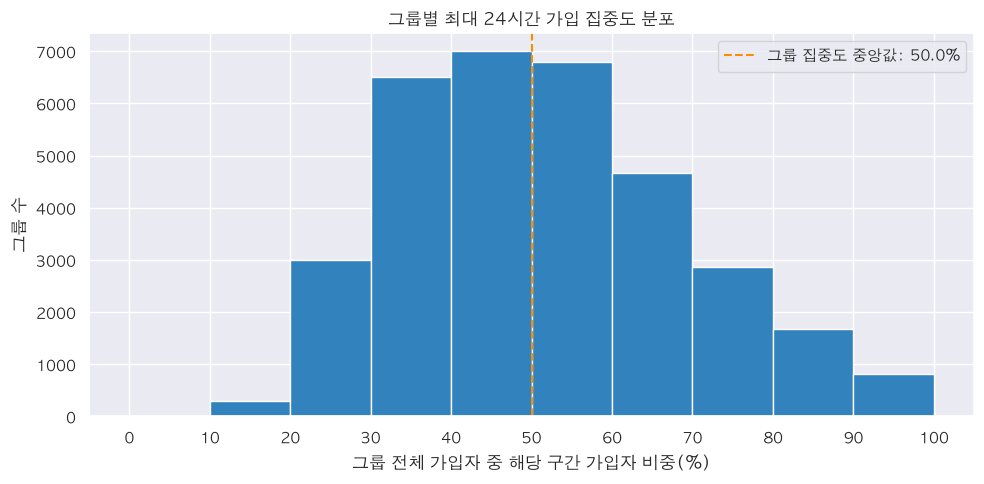

In [70]:
if group_burst_summary.empty:
    print('조건을 만족하는 그룹이 없습니다.')
else:
    concentration = group_burst_summary['가입 집중도(%)']
    median_concentration = concentration.median()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(
        concentration, bins=np.arange(0, 101, 10),
        color='#3182bd', edgecolor='white',
    )
    ax.axvline(
        median_concentration, color='darkorange', linestyle='--',
        label=f'그룹 집중도 중앙값: {median_concentration:.1f}%',
    )
    ax.set_title(f'그룹별 최대 {WINDOW_HOURS}시간 가입 집중도 분포')
    ax.set_xlabel('그룹 전체 가입자 중 해당 구간 가입자 비중(%)')
    ax.set_ylabel('그룹 수')
    ax.set_xticks(np.arange(0, 101, 10))
    ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)


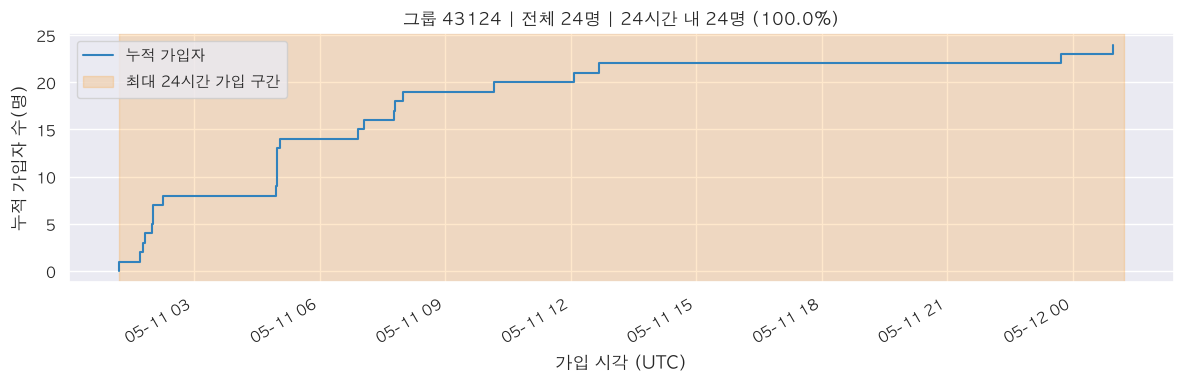

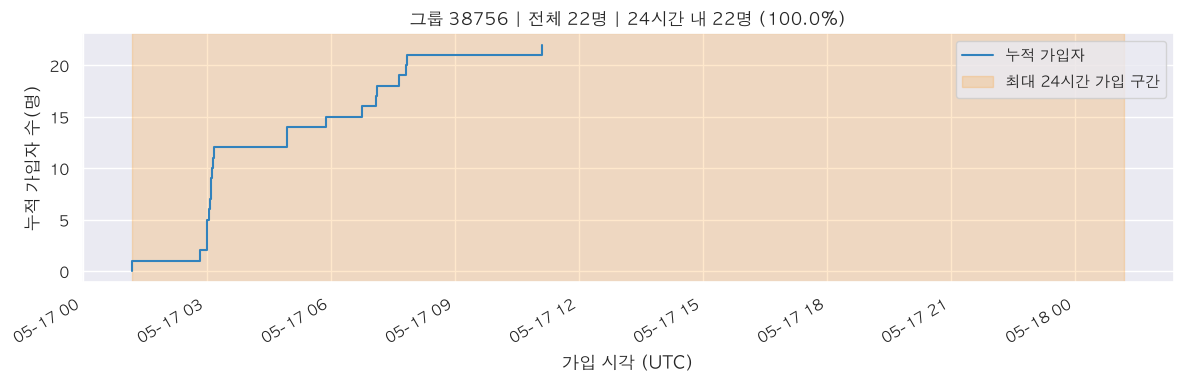

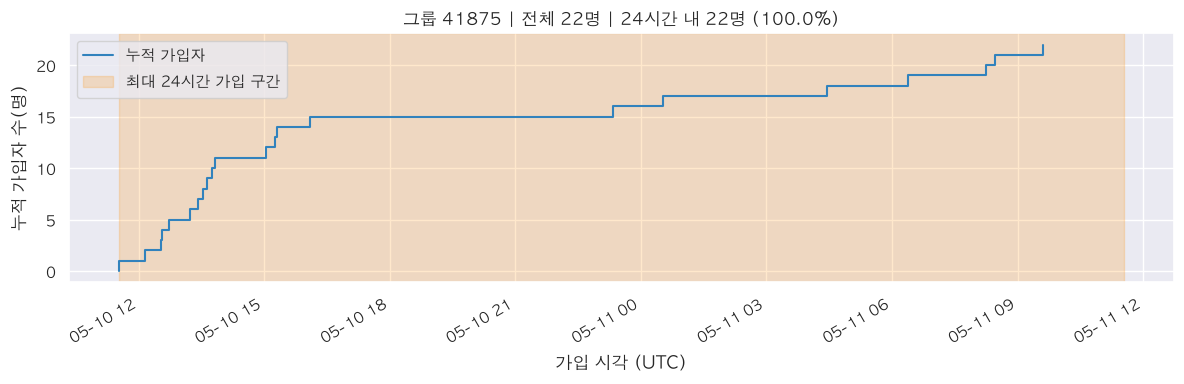

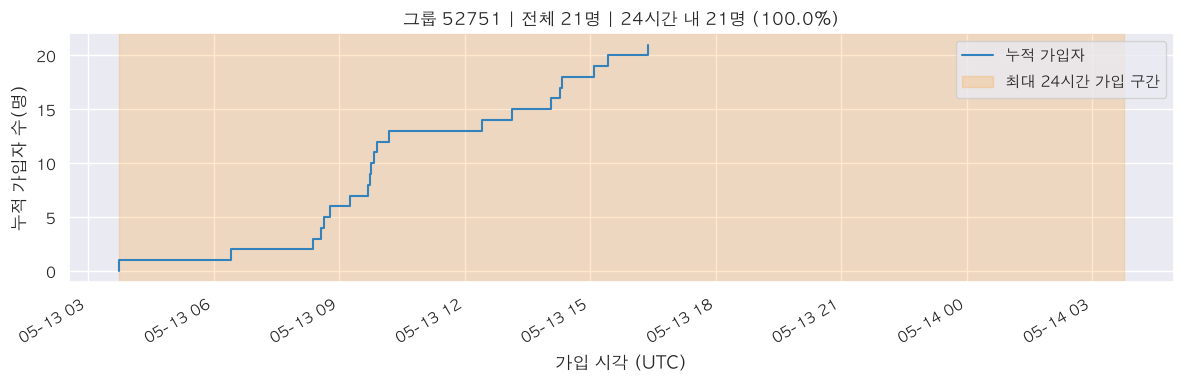

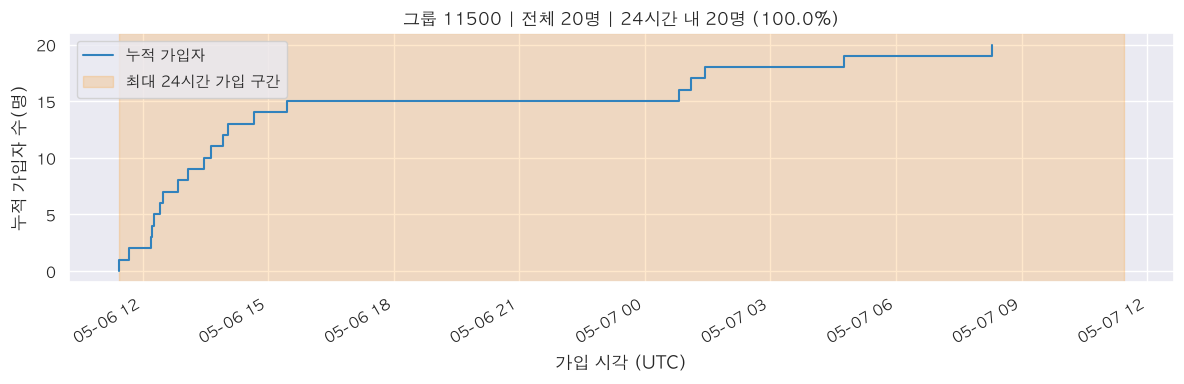

In [71]:
for _, result in group_burst_summary.head(5).iterrows():
    group_id = result['group_id']
    times = (
        analysis_signups.loc[
            analysis_signups['group_id'].eq(group_id), 'signup_date'
        ]
        .sort_values()
        .reset_index(drop=True)
    )
    plot_times = [times.iloc[0] - pd.Timedelta(seconds=1)] + times.tolist()
    cumulative_users = np.arange(len(times) + 1)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.step(
        plot_times, cumulative_users, where='post',
        color='#3182bd', label='누적 가입자',
    )
    ax.axvspan(
        result['집중 구간 시작'], result['집중 구간 종료(미포함)'],
        color='darkorange', alpha=0.2,
        label=f'최대 {WINDOW_HOURS}시간 가입 구간',
    )
    ax.set_title(
        f"그룹 {group_id} | 전체 {int(result['가입자 수']):,}명"
        f" | {WINDOW_HOURS}시간 내 {int(result['최대 구간 가입자 수']):,}명"
        f" ({result['가입 집중도(%)']:.1f}%)"
    )
    ax.set_xlabel(f'가입 시각 ({times.dt.tz or "원본 시간대"})')
    ax.set_ylabel('누적 가입자 수(명)')
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()
    plt.close(fig)


In [72]:
concentration = group_burst_summary['가입 집중도(%)']

# 0~10% 미만, …, 90~100% (마지막 구간은 100% 포함)
labels = [
    f'{start}~{start + 10}% 미만'
    for start in range(0, 90, 10)
] + ['90~100%']

bins = list(range(0, 100, 10)) + [float('inf')]

concentration_distribution = (
    pd.cut(
        concentration,
        bins=bins,
        labels=labels,
        right=False,
    )
    .value_counts(sort=False)
    .rename_axis('가입 집중도 구간')
    .reset_index(name='그룹 수')
)

concentration_distribution['그룹 비중(%)'] = (
    concentration_distribution['그룹 수']
    / len(group_burst_summary)
    * 100
).round(2)

display(concentration_distribution)

,가입 집중도 구간,그룹 수,그룹 비중(%)
0,0~10% 미만,0,0.00
1,10~20% 미만,296,0.88
2,20~30% 미만,2995,8.91
3,30~40% 미만,6516,19.38
4,40~50% 미만,6997,20.82
5,50~60% 미만,6802,20.24
6,60~70% 미만,4675,13.91
7,70~80% 미만,2855,8.49
8,80~90% 미만,1673,4.98
9,90~100%,806,2.40


In [73]:
# 동일한 그룹을 대상으로 1~5일의 연속 가입 집중도 비교
WINDOWS = [24, 48, 72, 96, 120]
burst_results = {}

for hours in WINDOWS:
    records = []
    for group_id, group in analysis_signups.groupby('group_id'):
        records.append({
            'group_id': group_id,
            **summarize_group_burst(group, window_hours=hours),
        })
    burst_results[hours] = pd.DataFrame(records, columns=burst_columns)

print(f'비교 시간 구간: {WINDOWS} / 분석 그룹 수: {len(burst_results[24]):,}개')


비교 시간 구간: [24, 48, 72, 96, 120] / 분석 그룹 수: 33,615개


In [74]:
# 집중도 구간별 그룹 비중: 각 열의 분모는 동일한 전체 분석 그룹 수
labels = [
    f'{start}~{start + 10}% 미만'
    for start in range(0, 90, 10)
] + ['90~100%']
bins = list(range(0, 100, 10)) + [float('inf')]

share_comparison = pd.DataFrame(
    index=pd.Index(labels, name='가입 집중도 구간')
)
for hours, data in burst_results.items():
    counts = pd.cut(
        data['가입 집중도(%)'],
        bins=bins, labels=labels, right=False,
    ).value_counts(sort=False)
    share_comparison[f'{hours}시간'] = (
        counts / len(data) * 100 if len(data) else float('nan')
    )

display(share_comparison.style.format('{:.2f}%', na_rep='분석 대상 없음'))


,24시간,48시간,72시간,96시간,120시간
가입 집중도 구간,,,,,
0~10% 미만,0.00%,0.00%,0.00%,0.00%,0.00%
10~20% 미만,0.88%,0.07%,0.01%,0.00%,0.00%
20~30% 미만,8.91%,1.89%,0.51%,0.15%,0.07%
30~40% 미만,19.38%,7.85%,3.31%,1.37%,0.66%
40~50% 미만,20.82%,13.00%,7.45%,4.30%,2.51%
50~60% 미만,20.24%,19.71%,14.24%,10.15%,7.11%
60~70% 미만,13.91%,18.57%,17.26%,13.76%,11.05%
70~80% 미만,8.49%,16.03%,18.57%,17.50%,15.71%
80~90% 미만,4.98%,13.26%,19.43%,22.82%,23.26%


In [75]:
# 시간 구간별 요약: 집중도 80%는 탐색용 비교 기준
window_summary = pd.DataFrame([
    {
        '시간 구간': f'{hours}시간',
        '분석 그룹 수': len(data),
        '평균 집중도(%)': data['가입 집중도(%)'].mean(),
        '중앙 집중도(%)': data['가입 집중도(%)'].median(),
        '집중도 80% 이상 그룹 비중(%)': (
            data['가입 집중도(%)'].ge(80).mean() * 100
        ),
    }
    for hours, data in burst_results.items()
])
display(window_summary.round(2))


,시간 구간,분석 그룹 수,평균 집중도(%),중앙 집중도(%),집중도 80% 이상 그룹 비중(%)
0,24시간,33615,50.45,50.00,7.37
1,48시간,33615,63.39,63.64,22.88
2,72시간,33615,71.55,72.73,38.67
3,96시간,33615,77.41,80.00,52.76
4,120시간,33615,81.47,84.62,62.89


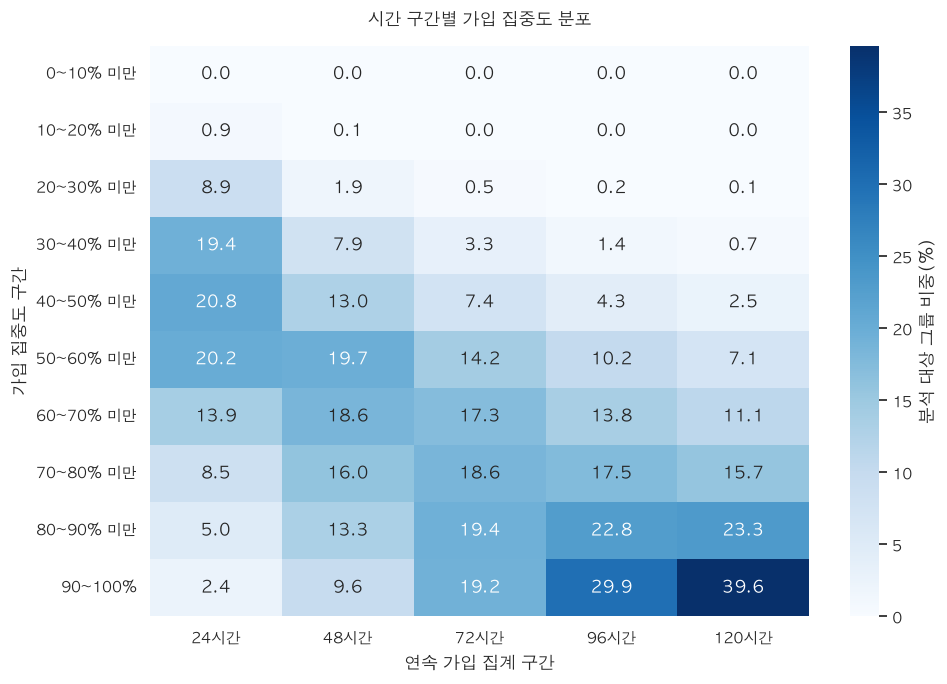

In [76]:
# 집계 기간이 길어지면 집중도는 같거나 높아지므로 구간 간 변화량을 비교합니다.
if share_comparison.isna().all().all():
    print('조건을 만족하는 그룹이 없어 히트맵을 표시하지 않습니다.')
else:
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(
        share_comparison,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        cbar_kws={'label': '분석 대상 그룹 비중(%)'},
        ax=ax,
    )
    ax.set_title('시간 구간별 가입 집중도 분포', pad=15)
    ax.set_xlabel('연속 가입 집계 구간')
    ax.set_ylabel('가입 집중도 구간')
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## 학교·학급 가입 집중도 비교

* 동일한 연속 24시간 기준으로 학교 전체와 소속 학급을 비교합니다.
* 가입자 10명 이상 학급이 2개 이상인 학교를 대상으로 합니다. 학교 집중도에는 작은 학급도 포함합니다.
* 학교 집중 구간에 각 학급 가입자가 얼마나 함께 가입했는지 확인합니다.
* 가입 당시 소속이 유지되었다고 가정하며, 가입 시각과 시간대는 변환하지 않습니다.
* 집중 구간이 여러 개면 가장 이른 구간을 사용합니다. 가입 시점만으로 실제 전파 경로를 확정하지 않습니다.


In [77]:
COMPARE_HOURS = 24
MIN_CLASS_USERS = 10

school_signups = (
    df[['user_id', 'school_id', 'group_id', 'signup_date']]
    .dropna(subset=['user_id', 'school_id', 'group_id', 'signup_date'])
    .sort_values('signup_date')
    .drop_duplicates(['school_id', 'group_id', 'user_id'], keep='first')
    .copy()
)

membership_counts = school_signups.groupby('user_id').size()
if membership_counts.gt(1).any():
    raise ValueError('동일 유저가 여러 학교·학급에 연결되어 있습니다. 중복 소속 처리 기준을 확인해 주세요.')

class_sizes = (
    school_signups.groupby(['school_id', 'group_id'])['user_id']
    .nunique()
    .reset_index(name='학급 가입자 수')
)
eligible_classes = class_sizes[class_sizes['학급 가입자 수'] >= MIN_CLASS_USERS]
eligible_school_ids = (
    eligible_classes.groupby('school_id').size()
    .loc[lambda counts: counts >= 2].index
)
print(f'전체 유효 학교 수: {school_signups["school_id"].nunique():,}개')
print(f'비교 대상 학교 수: {len(eligible_school_ids):,}개')


전체 유효 학교 수: 5,548개
비교 대상 학교 수: 3,556개


In [78]:
school_records = []
class_records = []
comparison_signups = school_signups[
    school_signups['school_id'].isin(eligible_school_ids)
]

for school_id, school in comparison_signups.groupby('school_id'):
    school_stats = summarize_group_burst(school, window_hours=COMPARE_HOURS)
    school_start = school_stats['집중 구간 시작']
    school_end = school_stats['집중 구간 종료(미포함)']
    sizes = school.groupby('group_id')['user_id'].nunique()
    eligible_sizes = sizes[sizes >= MIN_CLASS_USERS]

    school_records.append({
        'school_id': school_id,
        '학교 가입자 수': len(school),
        '가입 학급 수': len(sizes),
        '비교 대상 학급 수': len(eligible_sizes),
        '비교 대상 학급 가입자 비중(%)': eligible_sizes.sum() / len(school) * 100,
        '최대 학급 가입자 비중(%)': sizes.max() / len(school) * 100,
        '학교 가입 집중도(%)': school_stats['가입 집중도(%)'],
        '학교 집중 시작': school_start,
        '학교 집중 종료(미포함)': school_end,
    })

    for group_id, classroom in school.groupby('group_id'):
        if len(classroom) < MIN_CLASS_USERS:
            continue
        class_stats = summarize_group_burst(classroom, window_hours=COMPARE_HOURS)
        in_school_window = (
            classroom['signup_date'].ge(school_start)
            & classroom['signup_date'].lt(school_end)
        )
        class_records.append({
            'school_id': school_id,
            'group_id': group_id,
            '학급 가입자 수': len(classroom),
            '학급 가입 집중도(%)': class_stats['가입 집중도(%)'],
            '학교 집중 구간 내 학급 가입 비중(%)': in_school_window.mean() * 100,
            '학급 집중 시작': class_stats['집중 구간 시작'],
            '학급 집중 종료(미포함)': class_stats['집중 구간 종료(미포함)'],
        })

school_comparison = pd.DataFrame(school_records)
class_comparison = pd.DataFrame(class_records)
if school_comparison.empty:
    print('조건을 만족하는 학교가 없습니다.')
else:
    school_comparison = (
        school_comparison.sort_values('학교 가입자 수', ascending=False)
        .reset_index(drop=True)
    )
    display(school_comparison.round(2))


/var/folders/yd/3llw30vx5k3241gyl8_mwl_w0000gn/T/ipykernel_69621/1833362035.py:53: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(school_comparison.round(2))


,school_id,학교 가입자 수,가입 학급 수,비교 대상 학급 수,비교 대상 학급 가입자 비중(%),최대 학급 가입자 비중(%),학교 가입 집중도(%),학교 집중 시작,학교 집중 종료(미포함)
0,369,578,39,38,99.65,4.33,47.06,2023-05-02 21:55:12.427337+00:00,2023-05-03 21:55:12.427337+00:00
1,1719,551,31,30,99.82,4.36,33.58,2023-05-13 07:46:29.214131+00:00,2023-05-14 07:46:29.214131+00:00
2,4516,510,37,26,91.37,4.90,24.31,2023-05-05 08:37:40.435754+00:00,2023-05-06 08:37:40.435754+00:00
3,5372,507,37,31,91.52,4.34,40.83,2023-05-11 10:38:42.420803+00:00,2023-05-12 10:38:42.420803+00:00
4,5520,500,30,25,93.20,6.20,21.80,2023-05-09 09:02:18.300558+00:00,2023-05-10 09:02:18.300558+00:00
...,...,...,...,...,...,...,...,...,...
3551,4309,28,2,2,100.00,53.57,50.00,2023-05-23 12:40:45.895313+00:00,2023-05-24 12:40:45.895313+00:00
3552,4553,27,2,2,100.00,59.26,59.26,2023-05-17 12:02:16.681706+00:00,2023-05-18 12:02:16.681706+00:00
3553,4857,26,2,2,100.00,61.54,42.31,2023-05-11 15:20:19.342097+00:00,2023-05-12 15:20:19.342097+00:00
3554,1071,26,3,2,80.77,42.31,80.77,2023-05-22 23:21:07.012783+00:00,2023-05-23 23:21:07.012783+00:00


In [79]:
# 원하는 school_id를 지정하세요. None이면 가입자가 가장 많은 학교를 선택합니다.
selected_school_id = None
selected_classes = pd.DataFrame()

if not school_comparison.empty:
    if selected_school_id is None:
        selected_school_id = school_comparison.iloc[0]['school_id']
    if not school_comparison['school_id'].eq(selected_school_id).any():
        raise ValueError('비교 대상 학교 목록에 포함된 school_id를 선택해 주세요.')

    selected_classes = (
        class_comparison[class_comparison['school_id'].eq(selected_school_id)]
        .sort_values('학급 집중 시작')
        .reset_index(drop=True)
    )
    display(school_comparison[
        school_comparison['school_id'].eq(selected_school_id)
    ].round(2))
    display(selected_classes.round(2))


/var/folders/yd/3llw30vx5k3241gyl8_mwl_w0000gn/T/ipykernel_69621/3516057887.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2))


,school_id,학교 가입자 수,가입 학급 수,비교 대상 학급 수,비교 대상 학급 가입자 비중(%),최대 학급 가입자 비중(%),학교 가입 집중도(%),학교 집중 시작,학교 집중 종료(미포함)
0,369,578,39,38,99.65,4.33,47.06,2023-05-02 21:55:12.427337+00:00,2023-05-03 21:55:12.427337+00:00


/var/folders/yd/3llw30vx5k3241gyl8_mwl_w0000gn/T/ipykernel_69621/3516057887.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(selected_classes.round(2))


,school_id,group_id,학급 가입자 수,학급 가입 집중도(%),학교 집중 구간 내 학급 가입 비중(%),학급 집중 시작,학급 집중 종료(미포함)
0,369,4773,17,52.94,52.94,2023-05-02 13:08:56.928952+00:00,2023-05-03 13:08:56.928952+00:00
1,369,8512,25,80.00,76.00,2023-05-02 13:54:15.783202+00:00,2023-05-03 13:54:15.783202+00:00
2,369,8438,23,52.17,47.83,2023-05-02 14:41:06.074886+00:00,2023-05-03 14:41:06.074886+00:00
3,369,838,17,64.71,64.71,2023-05-02 15:01:34.944126+00:00,2023-05-03 15:01:34.944126+00:00
4,369,9771,19,68.42,68.42,2023-05-02 17:45:11.570539+00:00,2023-05-03 17:45:11.570539+00:00
5,369,9789,16,75.00,75.00,2023-05-02 21:55:12.427337+00:00,2023-05-03 21:55:12.427337+00:00
6,369,9820,19,68.42,68.42,2023-05-02 22:44:27.267798+00:00,2023-05-03 22:44:27.267798+00:00
7,369,8872,17,52.94,52.94,2023-05-02 22:49:46.683729+00:00,2023-05-03 22:49:46.683729+00:00
8,369,6513,16,62.50,62.50,2023-05-02 23:25:19.355895+00:00,2023-05-03 23:25:19.355895+00:00
9,369,321,16,56.25,56.25,2023-05-03 00:02:13.179833+00:00,2023-05-04 00:02:13.179833+00:00


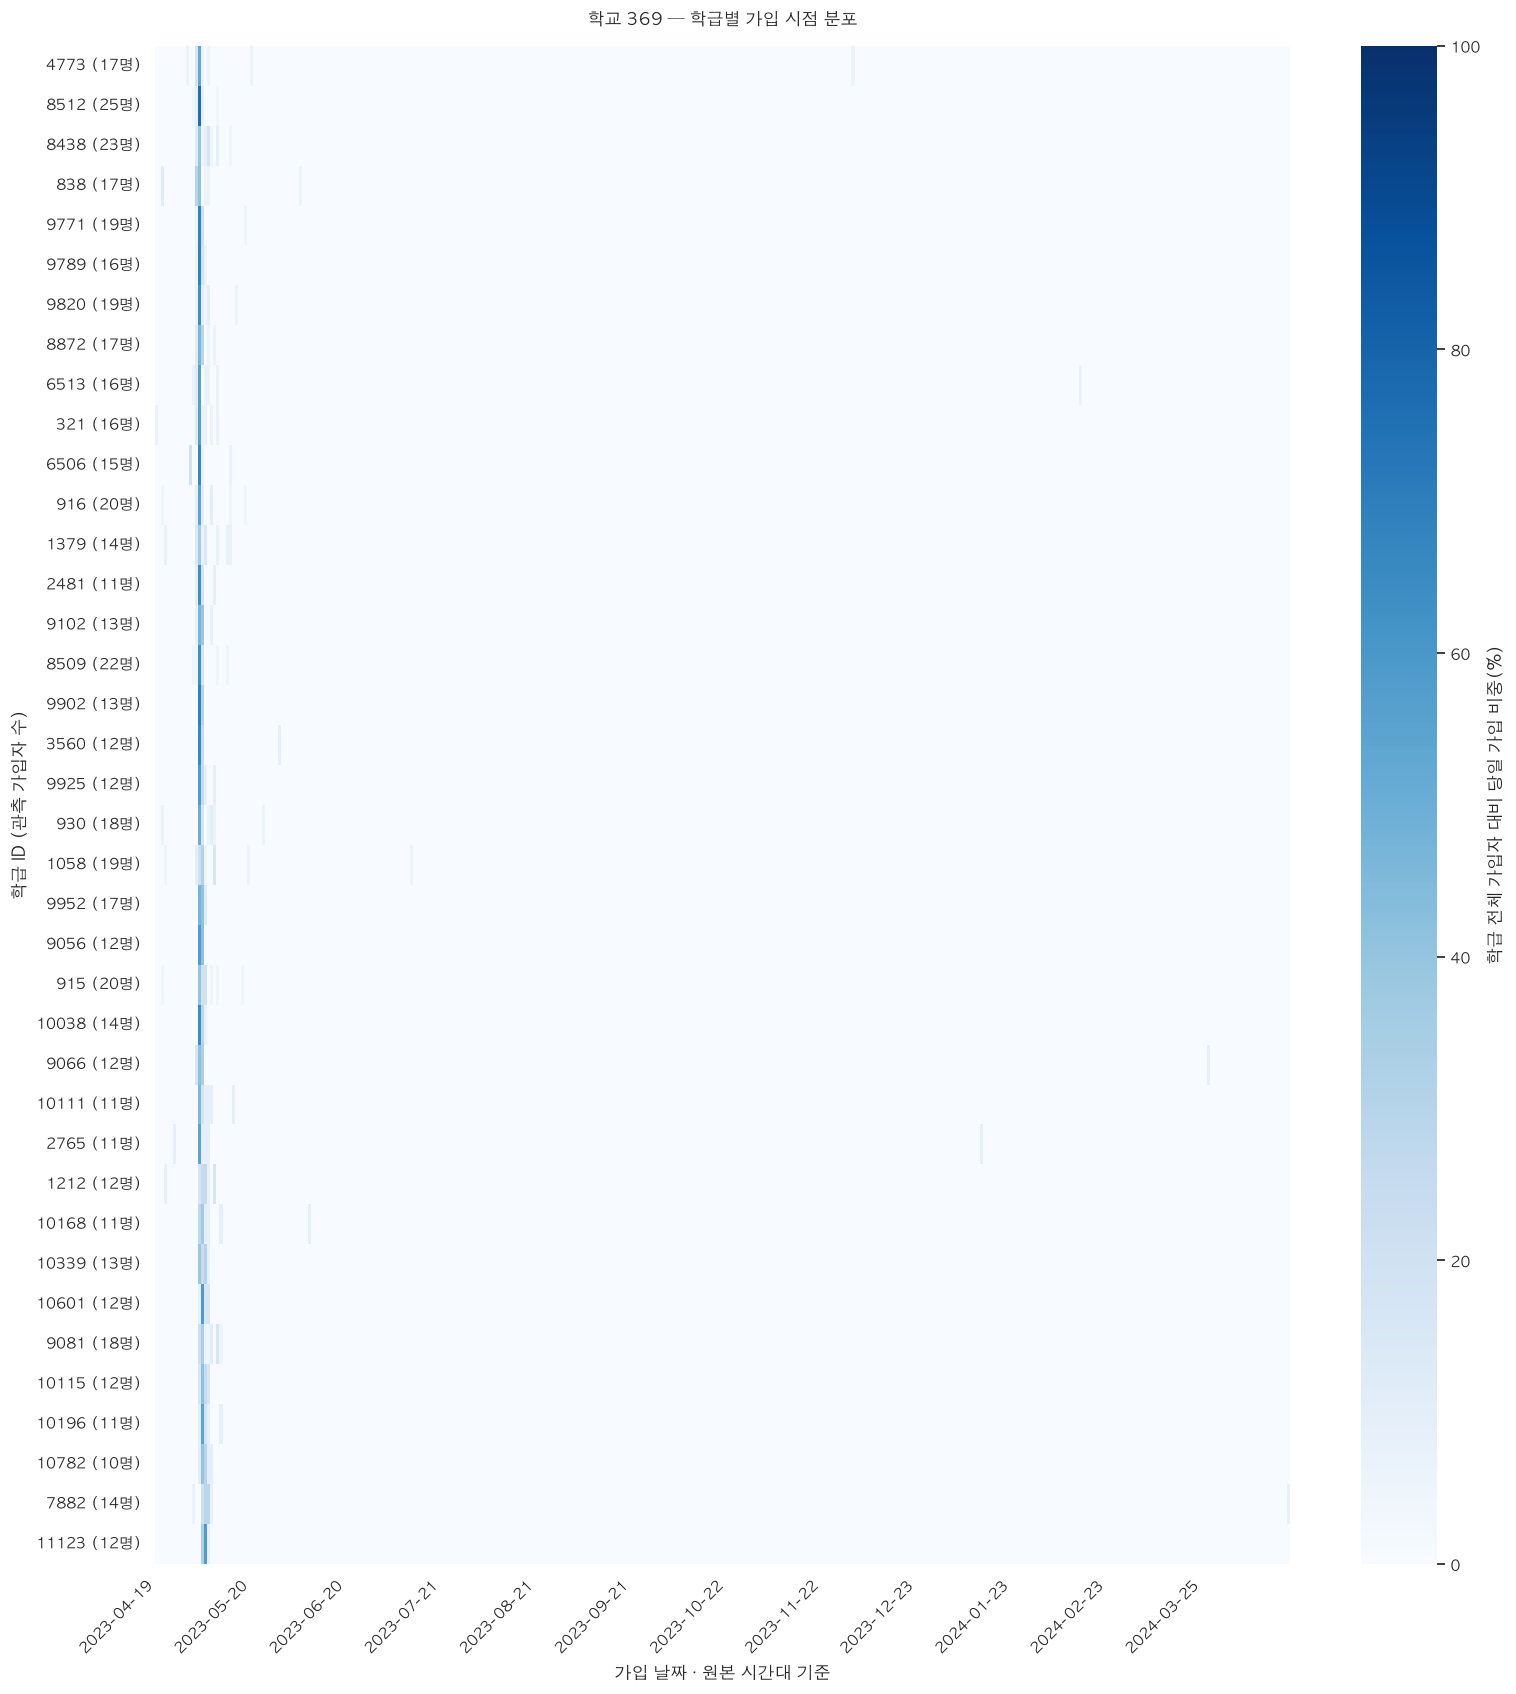

In [80]:
# 표는 연속 24시간 기준, 히트맵은 원본 시간대의 달력 날짜 기준입니다.
if not selected_classes.empty:
    selected_signups = comparison_signups[
        comparison_signups['school_id'].eq(selected_school_id)
        & comparison_signups['group_id'].isin(selected_classes['group_id'])
    ].copy()
    selected_signups['가입 날짜'] = selected_signups['signup_date'].dt.floor('D')
    daily_counts = (
        selected_signups.groupby(['group_id', '가입 날짜'])['user_id']
        .nunique().unstack(fill_value=0)
    )
    all_days = pd.date_range(
        selected_signups['가입 날짜'].min(),
        selected_signups['가입 날짜'].max(), freq='D',
    )
    daily_counts = (
        daily_counts.reindex(columns=all_days, fill_value=0)
        .reindex(index=selected_classes['group_id'])
    )
    class_totals = selected_classes.set_index('group_id')['학급 가입자 수']
    daily_share = daily_counts.div(class_totals, axis=0) * 100

    fig, ax = plt.subplots(figsize=(16, max(4, len(daily_share) * 0.45)))
    sns.heatmap(
        daily_share, cmap='Blues', vmin=0, vmax=100,
        xticklabels=False,
        yticklabels=[
            f'{group_id} ({int(class_totals.loc[group_id])}명)'
            for group_id in daily_share.index
        ],
        cbar_kws={'label': '학급 전체 가입자 대비 당일 가입 비중(%)'},
        ax=ax,
    )
    tick_step = max(1, (len(all_days) + 11) // 12)
    tick_positions = list(range(0, len(all_days), tick_step))
    ax.set_xticks([position + 0.5 for position in tick_positions])
    ax.set_xticklabels(
        [all_days[position].strftime('%Y-%m-%d') for position in tick_positions],
        rotation=45, ha='right',
    )
    ax.set_title(f'학교 {selected_school_id} — 학급별 가입 시점 분포', pad=15)
    ax.set_xlabel('가입 날짜 · 원본 시간대 기준')
    ax.set_ylabel('학급 ID (관측 가입자 수)')
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## 가입자 별 결제 규모 파악

In [81]:
# 전처리 수행 대상 테이블 호출
sql2 = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_paymenthistory` AS p
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.stg_acquisition_user` AS u
    ON p.user_id = u.user_id
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.product_price` AS pp
    ON p.productId = pp.product_id
"""

# 판다스 데이터프레임으로 변환
df2 = client.query(sql2).to_dataframe()

print(df2.head())

      id  productId phone_type                created_at  user_id  user_id_1  \
0  97315  heart.777          I 2023-11-12 06:03:43+00:00   937054     937054   
1  96875  heart.777          I 2023-09-21 15:06:00+00:00  1173477    1173477   
2  96876  heart.777          I 2023-09-21 15:06:00+00:00  1173477    1173477   
3  48708  heart.777          I 2023-05-21 11:34:09+00:00  1230722    1230722   
4  50561  heart.200          I 2023-05-21 15:03:42+00:00  1230722    1230722   

                       signup_date  group_id  grade  school_id      address  \
0 2023-05-07 02:35:24.651241+00:00     19147      2       2226    서울특별시 동작구   
1 2023-05-12 12:05:06.366820+00:00     21723      3       4961  경기도 안양시 동안구   
2 2023-05-12 12:05:06.366820+00:00     21723      3       4961  경기도 안양시 동안구   
3 2023-05-13 14:38:22.309286+00:00     41456      3       3860     경상북도 구미시   
4 2023-05-13 14:38:22.309286+00:00     41456      3       3860     경상북도 구미시   

  school_type product_id  price  
0         

In [85]:
# 지역별 결제 규모: 학교 소재지 및 상품 가격 기준
# 동일 결제 ID가 조인으로 증식했는지 확인
if df2['id'].duplicated().any():
    raise ValueError(
        '같은 결제 ID가 여러 행에 존재합니다. '
        '사용자·상품 가격 테이블의 조인 중복을 확인해 주세요.'
    )

# 기존 전처리 기준: 동일 유저·동일 시각은 최초 ID 한 건만 인정
payment_area = (
    df2.sort_values('id')
    .drop_duplicates(['user_id', 'created_at'], keep='first')
    .copy()
)

# ARPU 분모는 미결제자를 포함한 전체 가입자이며, 지역은 동일한 사용자 기준으로 연결
payment_user_base = df[['user_id', 'address']].drop_duplicates().copy()
if payment_user_base['user_id'].duplicated().any():
    raise ValueError('동일 유저에 여러 주소가 연결되어 있습니다. 지역 귀속 기준을 확인해 주세요.')

address = (
    payment_user_base['address'].astype('string').str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .replace({'-': pd.NA, '': pd.NA})
)
parts = address.str.split(n=2, expand=True).reindex(columns=[0, 1])
payment_user_base['시도'] = parts[0].fillna('미상')
payment_user_base['시군구'] = parts[1].fillna('미기재')

payment_area = payment_area.merge(
    payment_user_base[['user_id', '시도', '시군구']],
    on='user_id', how='left', validate='many_to_one', indicator=True,
)
if payment_area['_merge'].ne('both').any():
    raise ValueError('전체 가입자 데이터에 없는 결제자가 있습니다. df와 df2의 대상 범위를 확인해 주세요.')
payment_area = payment_area.drop(columns='_merge')

# 분모는 df2에 연결된 결제의 중복 정리 후 총금액
# INNER JOIN 미연결 결제는 포함되지 않으며, 환불 반영 순매출과 구분합니다.
total_payment = payment_area['price'].sum()


# 조회된 누적 결제금액 / 전체 가입자 기준이며, 월간 활성 사용자 기준 ARPU가 아닙니다.
def summarize_area_payment(data, group_cols):
    user_counts = (
        payment_user_base.groupby(group_cols)['user_id']
        .nunique().reset_index(name='가입자수')
    )
    payments = (
        data.groupby(group_cols)
        .agg(
            결제금액=('price', 'sum'),
            결제건수=('id', 'nunique'),
            결제자수=('user_id', 'nunique'),
        )
        .reset_index()
    )
    # 결제 이력이 없는 지역도 포함
    summary = user_counts.merge(
        payments, on=group_cols, how='left', validate='one_to_one'
    )
    payment_cols = ['결제금액', '결제건수', '결제자수']
    summary[payment_cols] = summary[payment_cols].fillna(0)
    summary[['결제건수', '결제자수']] = summary[['결제건수', '결제자수']].astype(int)

    summary['결제금액 비중(%)'] = (
        (summary['결제금액'] / total_payment * 100).round(2)
        if total_payment > 0 else float('nan')
    )
    summary['ARPU'] = (
        summary['결제금액'] / summary['가입자수'].replace(0, float('nan'))
    ).round(2)
    summary['ARPPU'] = (
        summary['결제금액'] / summary['결제자수'].replace(0, float('nan'))
    ).round(2)
    return summary.sort_values('결제금액', ascending=False).reset_index(drop=True)


region_payment_summary = summarize_area_payment(payment_area, ['시도'])
city_payment_summary = summarize_area_payment(payment_area, ['시도', '시군구'])

display(region_payment_summary)
display(city_payment_summary)


,시도,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU
0,경기도,191707,44335100,21189,14002,22.14,231.26,3166.34
1,전라남도,31571,17720100,8059,4448,8.85,561.28,3983.84
2,경상남도,41893,16223100,7759,4640,8.1,387.25,3496.36
3,서울특별시,74521,14301800,6722,4472,7.14,191.92,3198.08
4,전라북도,34448,13304900,6281,3885,6.64,386.23,3424.68
5,경상북도,30265,12085700,5733,3431,6.04,399.33,3522.5
6,충청남도,42776,11875300,5557,3441,5.93,277.62,3451.12
7,부산광역시,41087,11795600,5494,3514,5.89,287.09,3356.74
8,인천광역시,41286,11104000,5320,3430,5.55,268.95,3237.32
9,대구광역시,35147,9972800,4752,3033,4.98,283.75,3288.1


,시도,시군구,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU
0,전라북도,전주시,13492,4923900,2341,1450,2.46,364.95,3395.79
1,경기도,수원시,19764,3715900,1841,1289,1.86,188.01,2882.78
2,경기도,고양시,17530,3595600,1674,1140,1.8,205.11,3154.04
3,광주광역시,광산구,8791,3429700,1613,988,1.71,390.14,3471.36
4,경기도,화성시,16957,3289000,1590,1066,1.64,193.96,3085.37
...,...,...,...,...,...,...,...,...,...
224,충청북도,보은군,49,1900,1,1,0.0,38.78,1900.0
225,전라남도,구례군,20,1900,1,1,0.0,95.0,1900.0
226,강원도,양양군,67,1900,1,1,0.0,28.36,1900.0
227,경상남도,의령군,56,0,0,0,0.0,0.0,<NA>


In [90]:
display('도시별')
display(region_payment_summary.sort_values('결제금액', ascending=False).head())
display(region_payment_summary.sort_values('결제금액 비중(%)', ascending=False).head())
display(region_payment_summary.sort_values('ARPPU', ascending=False).head())

display('-----------')
display('시군구별')
display(city_payment_summary.sort_values('결제금액', ascending=False).head())
display(city_payment_summary.sort_values('결제금액 비중(%)', ascending=False).head())
display(city_payment_summary.sort_values('ARPPU', ascending=False).head())


'도시별'

,시도,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU
0,경기도,191707,44335100,21189,14002,22.14,231.26,3166.34
1,전라남도,31571,17720100,8059,4448,8.85,561.28,3983.84
2,경상남도,41893,16223100,7759,4640,8.1,387.25,3496.36
3,서울특별시,74521,14301800,6722,4472,7.14,191.92,3198.08
4,전라북도,34448,13304900,6281,3885,6.64,386.23,3424.68


,시도,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU
0,경기도,191707,44335100,21189,14002,22.14,231.26,3166.34
1,전라남도,31571,17720100,8059,4448,8.85,561.28,3983.84
2,경상남도,41893,16223100,7759,4640,8.1,387.25,3496.36
3,서울특별시,74521,14301800,6722,4472,7.14,191.92,3198.08
4,전라북도,34448,13304900,6281,3885,6.64,386.23,3424.68


,시도,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU
1,전라남도,31571,17720100,8059,4448,8.85,561.28,3983.84
11,강원도,19612,8361600,3804,2182,4.18,426.35,3832.08
5,경상북도,30265,12085700,5733,3431,6.04,399.33,3522.5
2,경상남도,41893,16223100,7759,4640,8.1,387.25,3496.36
6,충청남도,42776,11875300,5557,3441,5.93,277.62,3451.12


'-----------'

'시군구별'

,시도,시군구,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU
0,전라북도,전주시,13492,4923900,2341,1450,2.46,364.95,3395.79
1,경기도,수원시,19764,3715900,1841,1289,1.86,188.01,2882.78
2,경기도,고양시,17530,3595600,1674,1140,1.8,205.11,3154.04
3,광주광역시,광산구,8791,3429700,1613,988,1.71,390.14,3471.36
4,경기도,화성시,16957,3289000,1590,1066,1.64,193.96,3085.37


,시도,시군구,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU
0,전라북도,전주시,13492,4923900,2341,1450,2.46,364.95,3395.79
1,경기도,수원시,19764,3715900,1841,1289,1.86,188.01,2882.78
2,경기도,고양시,17530,3595600,1674,1140,1.8,205.11,3154.04
3,광주광역시,광산구,8791,3429700,1613,988,1.71,390.14,3471.36
4,경기도,화성시,16957,3289000,1590,1066,1.64,193.96,3085.37


,시도,시군구,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU
205,강원도,고성군,200,148900,71,20,0.07,744.5,7445.0
175,경상북도,영양군,194,305400,156,43,0.15,1574.23,7102.33
154,전라남도,신안군,338,391000,180,66,0.2,1156.8,5924.24
214,경상북도,군위군,116,56400,26,10,0.03,486.21,5640.0
127,전라남도,함평군,529,541000,230,99,0.27,1022.68,5464.65
